<a href="https://colab.research.google.com/github/juanes0789/Modelos-2---proyecto-de-aula/blob/main/py_Juan_Mosquera_Maria_Mosquera_Michael_Molina_01_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comprensión y contextualización del problema

El objetivo principal de este análisis es explorar el comportamiento de las transacciones financieras para identificar patrones y características que distinguen las operaciones legítimas de las fraudulentas. Este proceso incluye la evaluación de la calidad de los datos, la detección de anomalías e implementación de modelos de machine learning para la predicción de futuras transacciones fraudulentas.

Este proyecto se enfoca en el estudio de transacciones financieras fraudulentas en un entorno de alta concurrencia, con el propósito de comprender los patrones y factores asociados al fraude. La metodología abarca la exploración y preparación de datos, el uso de técnicas de análisis estadísticos y la visualización de gráficos para identificar distribuciones, relaciones entre variables y comportamientos atípicos. Se realizan procesos de imputación, limpieza, transformación y escalamiento de datos para mejorar la calidad y coherencia analítica. Los resultados buscan reconocer patrones de comportamiento relacionados con transacciones fraudulentas, proporcionando una base técnica y profesional para sistemas inteligentes de detección de fraude financiero.

## Descripción del Conjunto de Datos

Este análisis se basa en dos conjuntos de datos principales: la Tabla de Transacciones y la Tabla de Identidad.

### Tabla de Transacciones
Esta tabla contiene información detallada sobre cada transacción financiera:
*   **TransactionDT**: Diferencia de tiempo (timedelta) desde una fecha y hora de referencia específica (no es una marca de tiempo real).
*   **TransactionAMT**: Monto del pago de la transacción en USD.
*   **ProductCD**: Código de producto, que indica el tipo de producto asociado a cada transacción.
*   **card1 - card6**: Información de la tarjeta de pago, incluyendo tipo de tarjeta, categoría, banco emisor, país, entre otros detalles. (El significado exacto está enmascarado).
*   **addr**: Información de la dirección.
*   **dist**: Información de distancia.
*   **P_ and (R__) emaildomain**: Dominio de correo electrónico del comprador (P_) y del destinatario (R__).
*   **C1-C14**: Variables de conteo, como cuántas direcciones están asociadas con una tarjeta de pago. (El significado exacto está enmascarado).
*   **D1-D15**: Diferencias de tiempo (timedelta), como los días transcurridos desde la transacción anterior.
*   **M1-M9**: Variables de coincidencia, que indican si los nombres en la tarjeta y la dirección, entre otros, coinciden.
*   **Vxxx**: Características ricas diseñadas por Vesta, que incluyen rankings, conteos y otras relaciones de entidades. (El significado exacto está enmascarado).
*   **Categorical Features**: `ProductCD`, `card1 - card6`, `addr1`, `addr2`, `P_emaildomain`, `R_emaildomain`, `M1 - M9`.

### Tabla de Identidad
Esta tabla contiene información de identidad, como detalles de conexión de red (IP, ISP, Proxy, etc.) y firma digital (UA/navegador/SO/versión, etc.) asociadas con las transacciones. Estos datos son recolectados por el sistema de protección contra fraude de Vesta y sus socios de seguridad digital. (Los nombres de los campos están enmascarados y no se proporcionará un diccionario de pares por razones de privacidad y acuerdos contractuales).
*   **Categorical Features**: `DeviceType`, `DeviceInfo`, `id_12 - id_38`.

In [ ]:
import pandas as pd # Importa la librería pandas para manipulación y análisis de datos.
import numpy as np # Importa numpy para operaciones numéricas y arrays.
import matplotlib.pyplot as plt # Importa matplotlib.pyplot para la creación de gráficos.
import seaborn as sns # Importa seaborn para visualizaciones estadísticas mejoradas.
import warnings # Importa la librería warnings para manejar advertencias.
warnings.filterwarnings('ignore') # Ignora todas las advertencias para una salida más limpia.

In [ ]:
# Carga de los conjuntos de datos desde archivos CSV
train_identity = pd.read_csv('train_identity.csv') # Carga datos de identidad de transacciones.
train_transaction = pd.read_csv('train_transaction.csv') # Carga datos de transacciones.

# Unión de los conjuntos de datos mediante 'TransactionID' para consolidar la información
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# Verificación de dimensiones y visualización inicial de las primeras filas del DataFrame consolidado
print('Dimensiones del DataFrame consolidado:', df.shape) # Muestra el número de filas y columnas.
display(df.head()) # Muestra las primeras 5 filas del DataFrame.

Dimensiones del DataFrame consolidado: (308145, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


,Clase,Cantidad,Porcentaje
0,No Fraude,297724,96.618151
1,Fraude,10421,3.381849


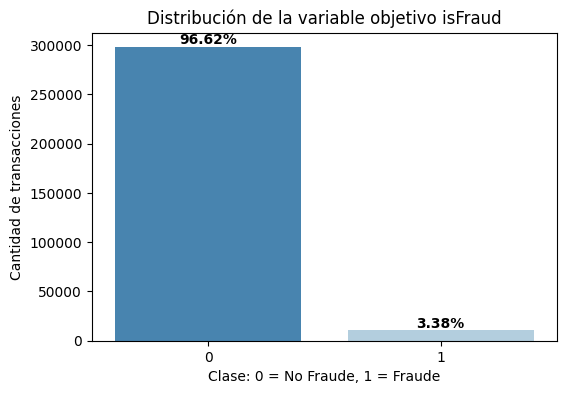

In [ ]:
# Análisis de la distribución de la variable objetivo 'isFraud'
# 'isFraud' indica si una transacción es fraudulenta (1) o no (0).
target_counts = df['isFraud'].value_counts() # Cuenta la cantidad de transacciones por clase.
target_percent = df['isFraud'].value_counts(normalize=True) * 100 # Calcula el porcentaje de transacciones por clase.

# Crea un DataFrame para resumir la distribución de la variable objetivo
target_summary = pd.DataFrame({
    'Clase': ['No Fraude', 'Fraude'],
    'Cantidad': [target_counts[0], target_counts[1]],
    'Porcentaje': [target_percent[0], target_percent[1]]
})

display(target_summary) # Muestra el resumen de la distribución.

# Visualización de la distribución de 'isFraud' usando un gráfico de barras
plt.figure(figsize=(6,4)) # Define el tamaño de la figura.
ax = sns.countplot(data=df, x='isFraud', palette='Blues_r') # Crea el gráfico de barras.

# Añade etiquetas de porcentaje sobre cada barra
for p in ax.patches:
    porcentaje = 100 * p.get_height() / len(df) # Calcula el porcentaje.
    ax.annotate(f'{porcentaje:.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()), # Posición de la etiqueta.
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold')

plt.title('Distribución de la variable objetivo isFraud') # Título del gráfico.
plt.xlabel('Clase: 0 = No Fraude, 1 = Fraude') # Etiqueta del eje X.
plt.ylabel('Cantidad de transacciones') # Etiqueta del eje Y.
plt.show() # Muestra el gráfico.

La variable objetivo presenta un fuerte desbalance de clases. La mayoría de las transacciones corresponden a operaciones legítimas (No Fraude), mientras que los casos fraudulentos representan una proporción significativamente menor del conjunto de datos. Esta distribución es característica de los problemas reales de detección de fraude y deberá ser considerada en las etapas posteriores de análisis y modelado.


In [ ]:
# Muestra el número total de registros (filas) y variables (columnas) en el DataFrame.
print(f"Número de registros: {df.shape[0]}") # Imprime la cantidad de filas.
print(f"Número de variables: {df.shape[1]}") # Imprime la cantidad de columnas.

Número de registros: 308145
Número de variables: 434


In [ ]:
# Muestra la distribución de los tipos de datos presentes en el DataFrame.
print("\nTipos de datos por variable:") # Título de la sección.
print(df.dtypes.value_counts()) # Cuenta cuántas variables hay por cada tipo de dato.


Tipos de datos por variable:
float64    399
object      31
int64        4
Name: count, dtype: int64


## Diagnostico de Calidad de datos

,variable,porcentaje_faltantes
0,id_24,99.013127
1,id_25,98.936864
2,id_07,98.933943
3,id_08,98.933943
4,id_21,98.932970
5,id_26,98.931996
6,id_27,98.931672
7,id_22,98.931672
8,id_23,98.931672
9,D7,93.518960


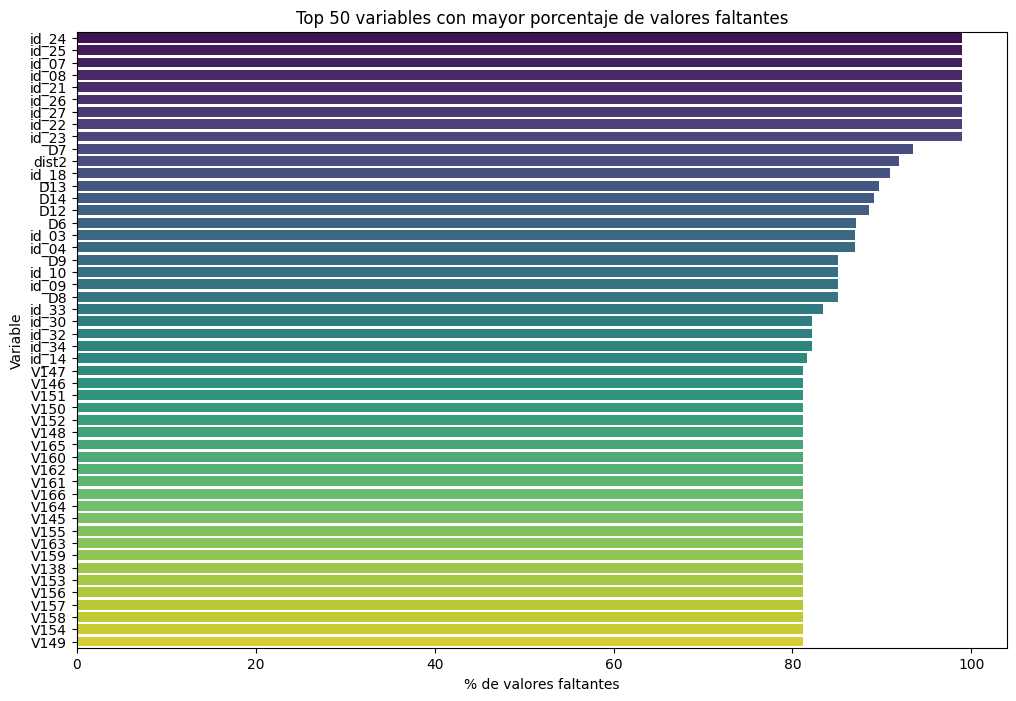

In [ ]:
# Calcula el porcentaje de valores faltantes para cada columna y los ordena de forma descendente.
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100

# Crea un DataFrame para mostrar el porcentaje de valores faltantes por variable.
missing_df = pd.DataFrame({'variable': missing_percent.index,'porcentaje_faltantes': missing_percent.values})

display(missing_df.head(50)) # Muestra las 50 variables con mayor porcentaje de faltantes.

# Visualiza las 50 variables con mayor porcentaje de valores faltantes mediante un gráfico de barras.
plt.figure(figsize=(12,8)) # Define el tamaño de la figura.
sns.barplot(data=missing_df.head(50),x='porcentaje_faltantes',y='variable',palette='viridis') # Crea el gráfico.
plt.title('Top 50 variables con mayor porcentaje de valores faltantes') # Título del gráfico.
plt.xlabel('% de valores faltantes') # Etiqueta del eje X.
plt.ylabel('Variable') # Etiqueta del eje Y.
plt.show() # Muestra el gráfico.

Verificación de variables numéricas con la variable objetivo, con el fin de identificar cuales variables se pueden descartar de nuestro estudio antes de realizar su respectivo análisis

In [ ]:
# Correlación de variables numéricas con isFraud
numeric_df = df.select_dtypes(include=np.number)

corr_fraud = numeric_df.corr()['isFraud'].sort_values(ascending=False)

corr_fraud_df = pd.DataFrame({
    'variable': corr_fraud.index,
    'correlacion_isFraud': corr_fraud.values
})

# Unir porcentaje de faltantes con correlación
decision_df = missing_df.merge(corr_fraud_df, on='variable', how='left')

# Regla de decisión
decision_df['accion'] = np.where(
    (decision_df['porcentaje_faltantes'] > 50) &
    (decision_df['correlacion_isFraud'].abs() < 0.05),
    'Eliminar',
    'Conservar o evaluar'
)

display(decision_df.head(80))

,variable,porcentaje_faltantes,correlacion_isFraud,accion
0,id_24,99.013127,-0.080397,Conservar o evaluar
1,id_25,98.936864,0.034726,Eliminar
2,id_07,98.933943,-0.036677,Eliminar
3,id_08,98.933943,-0.051693,Conservar o evaluar
4,id_21,98.932970,0.053702,Conservar o evaluar
...,...,...,...,...
75,M8,75.604018,NaN,Conservar o evaluar
76,M9,75.604018,NaN,Conservar o evaluar
77,DeviceInfo,75.170780,NaN,Conservar o evaluar
78,id_13,74.923818,-0.020517,Eliminar


In [ ]:
corr_fraud = (numeric_df.corr()['isFraud'].drop('isFraud'))

In [ ]:
corr_fraud.abs().sort_values(ascending=False).head(30)

,isFraud
V257,0.358924
V244,0.346288
V242,0.338127
V246,0.333212
V201,0.332644
V189,0.324471
V200,0.310054
V188,0.303671
V233,0.301245
V156,0.289333


### **¿Cuáles de las variables más correlacionadas tienen más del 70% de faltantes?**

In [ ]:
top_corr = corr_fraud.abs().sort_values(ascending=False).head(30)

for var in top_corr.index:
    print(f"{var:10} | Corr={corr_fraud[var]:.3f} | Missing={missing_percent[var]:.2f}%")

V257       | Corr=0.359 | Missing=72.94%
V244       | Corr=0.346 | Missing=72.94%
V242       | Corr=0.338 | Missing=72.94%
V246       | Corr=0.333 | Missing=72.94%
V201       | Corr=0.333 | Missing=71.60%
V189       | Corr=0.324 | Missing=71.60%
V200       | Corr=0.310 | Missing=71.60%
V188       | Corr=0.304 | Missing=71.60%
V233       | Corr=0.301 | Missing=72.94%
V156       | Corr=0.289 | Missing=81.16%
V149       | Corr=0.284 | Missing=81.16%
V158       | Corr=0.284 | Missing=81.16%
V231       | Corr=0.277 | Missing=72.94%
V217       | Corr=0.274 | Missing=72.94%
V45        | Corr=0.274 | Missing=32.80%
V232       | Corr=0.268 | Missing=72.94%
V171       | Corr=0.260 | Missing=71.60%
V228       | Corr=0.254 | Missing=72.94%
V147       | Corr=0.252 | Missing=81.16%
V44        | Corr=0.250 | Missing=32.80%
V87        | Corr=0.249 | Missing=19.18%
V86        | Corr=0.246 | Missing=19.18%
V258       | Corr=0.244 | Missing=72.94%
V155       | Corr=0.237 | Missing=81.16%
V170       | Cor

### **Clasificación de variables según relevancia**

In [ ]:
top_corr = corr_fraud.abs().sort_values(ascending=False).head(30)

top_variables = pd.DataFrame({
    'Variable': top_corr.index,
    'Correlacion': top_corr.values,
    'Missing (%)': [missing_percent[var] for var in top_corr.index]
})

display(top_variables)

,Variable,Correlacion,Missing (%)
0,V257,0.358924,72.942933
1,V244,0.346288,72.942933
2,V242,0.338127,72.942933
3,V246,0.333212,72.942933
4,V201,0.332644,71.600058
5,V189,0.324471,71.600058
6,V200,0.310054,71.600058
7,V188,0.303671,71.600058
8,V233,0.301245,72.942933
9,V156,0.289333,81.162115


El análisis de correlación evidenció que varias variables presentan una relación significativa con la ocurrencia de fraude financiero. Se identificaron variables como id_22, V201, V189, V200 y V257 con coeficientes de correlación superiores a 0.29 respecto a la variable objetivo. Aunque algunas de estas variables presentan porcentajes elevados de valores faltantes, su capacidad explicativa sugiere que no deben ser eliminadas automáticamente. Por esta razón, la decisión de conservación o eliminación de variables se fundamentó en una evaluación conjunta del porcentaje de datos faltantes y su relación con el fraude.

In [ ]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 308145
Número de variables: 434


In [ ]:
cols_eliminar = decision_df[
    (decision_df['porcentaje_faltantes'] > 50) &
    (decision_df['correlacion_isFraud'].abs() < 0.05)
]['variable'].tolist()

len(cols_eliminar)

100

Luego la verificación sobre columnas con cantidad de datos faltantes mayor al 50% y poca correlación con nuestra variable objetivo, se proceden a eliminar antes del análisis exploratorio

In [ ]:
df_clean = df.drop(columns=cols_eliminar)

print("Dimensiones originales:", df.shape)
print("Dimensiones después de limpieza:", df_clean.shape)

Dimensiones originales: (308145, 434)
Dimensiones después de limpieza: (308145, 334)


# Imputación de valores nulos y transformación

Después de eliminar las variables con alto porcentaje de ausencia y baja relación con isFraud, se procedió al tratamiento de los valores faltantes restantes. Para evitar pérdida adicional de información, se conservaron las variables relevantes y se aplicaron estrategias diferenciadas según el tipo de dato.

En las variables numéricas se utilizó la mediana, debido a que es una medida robusta ante valores extremos, especialmente importante en un problema de fraude financiero. En las variables categóricas se imputó la categoría "Unknown", con el fin de conservar la ausencia como una posible señal informativa. Además, se crearon indicadores binarios para marcar qué registros tenían valores faltantes originalmente.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("---- INICIO DEL PIPELINE DE IMPUTACIÓN Y TRANSFORMACIÓN ----")

# Se parte del dataset previamente depurado
df_imputed = df_clean.copy()

print("Dimensiones antes de imputar:", df_imputed.shape)
print("Valores nulos antes de imputar:", df_imputed.isnull().sum().sum())

# ============================================================
# FASE 1. CREACIÓN DE INDICADORES DE AUSENCIA
# ============================================================

# Identificar columnas con valores faltantes
cols_con_nulos = df_imputed.columns[
    df_imputed.isnull().sum() > 0
]

print("Variables con valores faltantes:", len(cols_con_nulos))

# Crear una variable indicadora por cada columna con valores faltantes
for col in cols_con_nulos:
    df_imputed[f'{col}_was_null'] = df_imputed[col].isnull().astype(int)

print("Indicadores de ausencia creados:", len(cols_con_nulos))
print("Dimensiones después de crear indicadores:", df_imputed.shape)

# ============================================================
# FASE 2. SELECCIÓN DE VARIABLES PARA IMPUTACIÓN KNN
# ============================================================

# Variables del bloque C
cols_C = [col for col in df_imputed.columns
    if col.startswith('C') and df_imputed[col].dtype != 'object'
]

# Variables del bloque D
cols_D = [col for col in df_imputed.columns
    if col.startswith('D') and df_imputed[col].dtype != 'object'
]

# Se incluye TransactionAmt por contexto del negocio
cols_knn = ['TransactionAmt'] + cols_C + cols_D

# Conservar únicamente columnas existentes, numéricas y con al menos un valor faltante
cols_knn = [
    col for col in cols_knn
    if col in df_imputed.columns
    and pd.api.types.is_numeric_dtype(df_imputed[col])
    and df_imputed[col].isnull().sum() > 0
]

print("Variables seleccionadas para imputación KNN:")
print(cols_knn)
print("Cantidad de variables imputadas con KNN:", len(cols_knn))

# ============================================================
# FASE 3. IMPUTACIÓN MULTIVARIADA MEDIANTE KNN
# ============================================================

if len(cols_knn) > 0:

    # Escalamiento
    scaler_knn = MinMaxScaler()

    data_knn = df_imputed[cols_knn].copy()
    data_knn_scaled = scaler_knn.fit_transform(data_knn)

    # Imputación KNN
    knn_imputer = KNNImputer(
        n_neighbors=5,
        weights='distance'
    )

    data_knn_imputed_scaled = knn_imputer.fit_transform(data_knn_scaled)

    # Retornar a escala original
    data_knn_imputed = scaler_knn.inverse_transform(
        data_knn_imputed_scaled
    )

    # Reemplazar en el dataset
    df_imputed[cols_knn] = data_knn_imputed

    print("Imputación KNN finalizada correctamente.")

else:
    print("No se encontraron variables numéricas con nulos para KNN.")

# ============================================================
# FASE 4. IMPUTACIÓN NUMÉRICA RESTANTE CON MEDIANA
# ============================================================

num_cols = df_imputed.select_dtypes(include=np.number).columns

cols_num_restantes = []

for col in num_cols:
    if col != 'isFraud' and df_imputed[col].isnull().sum() > 0:
        cols_num_restantes.append(col)
        df_imputed[col] = df_imputed[col].fillna(
            df_imputed[col].median()
        )

print("Variables numéricas imputadas con mediana:", len(cols_num_restantes))
print(cols_num_restantes[:30])


# ============================================================
# FASE 5. IMPUTACIÓN CATEGÓRICA CON UNKNOWN
# ============================================================

cat_cols = df_imputed.select_dtypes(exclude=np.number).columns

cols_cat_imputadas = []

for col in cat_cols:
    if df_imputed[col].isnull().sum() > 0:
        cols_cat_imputadas.append(col)
        df_imputed[col] = df_imputed[col].fillna('Unknown')

print("Variables categóricas imputadas con Unknown:", len(cols_cat_imputadas))
print(cols_cat_imputadas)


# ============================================================
# FASE 6. TRANSFORMACIÓN DE TransactionAmt
# ============================================================

scaler_transaction = StandardScaler()

df_imputed['TransactionAmt_scaled'] = scaler_transaction.fit_transform(
    df_imputed[['TransactionAmt']]
)

print("Variable TransactionAmt_scaled creada correctamente.")


# ============================================================
# FASE 7. AUDITORÍA FINAL DE INTEGRIDAD
# ============================================================

total_nulos_final = df_imputed.isnull().sum().sum()

print("Dimensiones finales:", df_imputed.shape)
print("Total de valores nulos finales:", total_nulos_final)

missing_final = (
    df_imputed
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_final.head(20))

if total_nulos_final == 0:
    print("El dataset imputado no presenta valores nulos.")
else:
    print("Aún existen valores nulos por revisar.")




---- INICIO DEL PIPELINE DE IMPUTACIÓN Y TRANSFORMACIÓN ----
Dimensiones antes de imputar: (308145, 334)
Valores nulos antes de imputar: 36432159
Variables con valores faltantes: 271
Indicadores de ausencia creados: 271
Dimensiones después de crear indicadores: (308145, 605)
Variables seleccionadas para imputación KNN:
['D1', 'D2', 'D3', 'D4', 'D5', 'D7', 'D8', 'D10', 'D15']
Cantidad de variables imputadas con KNN: 9


KeyboardInterrupt: 

# Detección de atípicos

In [ ]:
corr_fraude = df_clean.corr(numeric_only=True)['isFraud'].abs()

top20_corr = corr_fraude.sort_values(ascending=False).drop('isFraud')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

print("--- DIAGNÓSTICO COMPARATIVO DE VALORES ATÍPICOS ---")

# Subconjunto usado en la metodología
vars_atipicos = ['TransactionAmt', 'C1', 'isFraud']

df_atipicos = df_clean[vars_atipicos].dropna().copy()

X = df_atipicos[['TransactionAmt', 'C1']]
y = df_atipicos['isFraud']

print("Registros evaluados:", len(df_atipicos))

# =========================
# 1. Método IQR
# =========================

Q1 = df_atipicos['TransactionAmt'].quantile(0.25)
Q3 = df_atipicos['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

df_atipicos['IQR'] = np.where(df_atipicos['TransactionAmt'] > limite_superior, 'Atípico', 'Normal')

# =========================
# 2. Isolation Forest
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.03, random_state=42)

df_atipicos['Isolation Forest'] = np.where(iso.fit_predict(X_scaled) == -1, 'Atípico','Normal')

# =========================
# 3. k-NN basado en distancia
# =========================

knn = NearestNeighbors(n_neighbors=5)

knn.fit(X_scaled)

distancias, indices = knn.kneighbors(X_scaled)

df_atipicos['knn_score'] = distancias.mean(axis=1)

umbral_knn = df_atipicos['knn_score'].quantile(0.97)

df_atipicos['k-NN'] = np.where(df_atipicos['knn_score'] > umbral_knn, 'Atípico', 'Normal')

# =========================
# 4. Resumen comparativo
# =========================

metodos = ['IQR', 'Isolation Forest', 'k-NN']

resumen = []

for metodo in metodos:
    df_temp = df_atipicos[df_atipicos[metodo] == 'Atípico']

    total_atipicos = len(df_temp)
    fraudes_detectados = df_temp['isFraud'].sum()
    porcentaje_fraude = df_temp['isFraud'].mean() * 100 if total_atipicos > 0 else 0

    resumen.append({
        'Método': metodo,
        'Atípicos detectados': total_atipicos,
        'Fraudes dentro de atípicos': int(fraudes_detectados),
        '% Fraude dentro de atípicos': porcentaje_fraude
    })

resumen_atipicos = pd.DataFrame(resumen)

display(resumen_atipicos.round(2))

--- DIAGNÓSTICO COMPARATIVO DE VALORES ATÍPICOS ---
Registros evaluados: 155504


,Método,Atípicos detectados,Fraudes dentro de atípicos,% Fraude dentro de atípicos
0,IQR,15184,578,3.81
1,Isolation Forest,4665,287,6.15
2,k-NN,4666,340,7.29


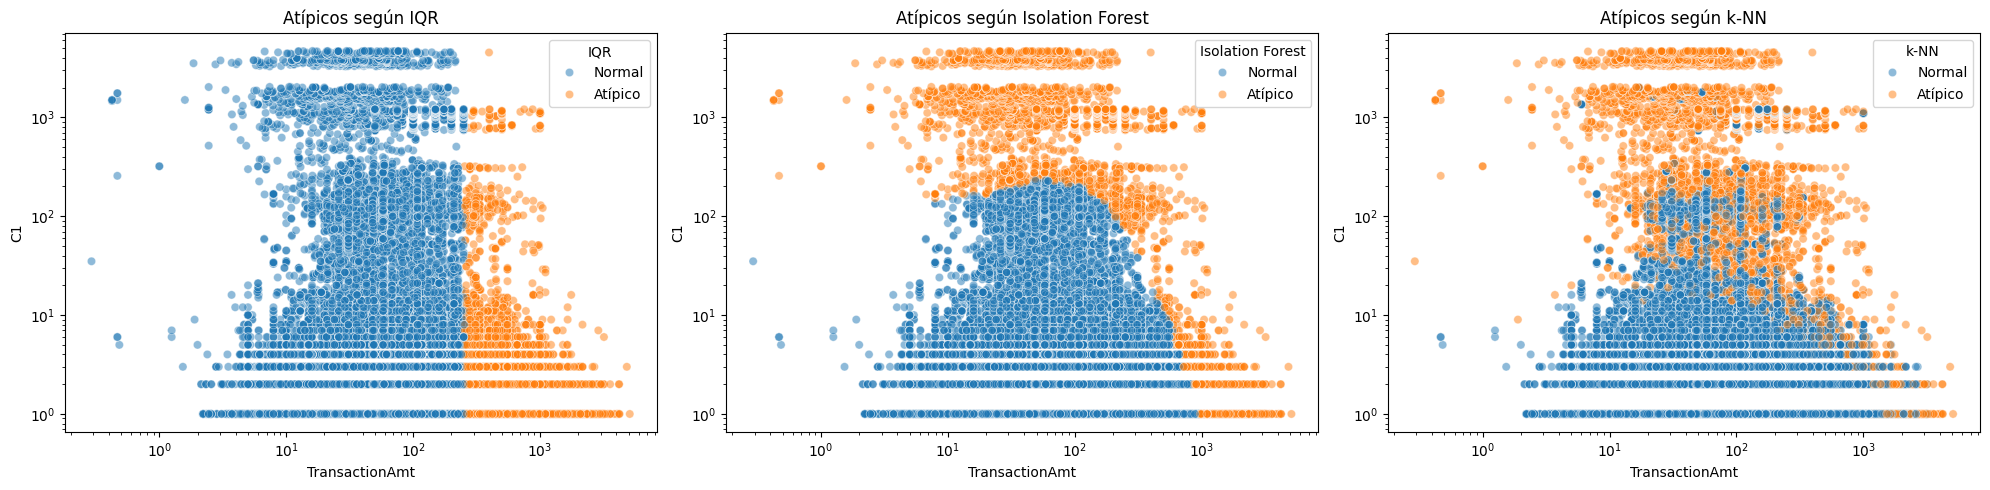

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metodo in zip(axes, metodos):
    sns.scatterplot(data=df_atipicos, x='TransactionAmt', y='C1', hue=metodo, alpha=0.5, ax=ax
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Atípicos según {metodo}')
    ax.set_xlabel('TransactionAmt')
    ax.set_ylabel('C1')

plt.tight_layout()
plt.show()

#  Análisis exploratorio de datos (EDA)

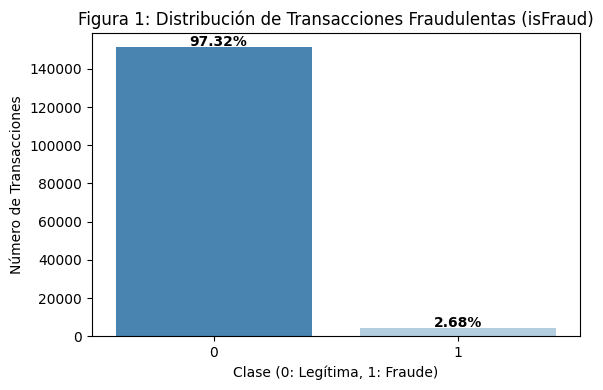

isFraud
0    151332
1      4172
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='isFraud', data=df, palette='Blues_r')
plt.title('Figura 1: Distribución de Transacciones Fraudulentas (isFraud)', fontsize=12)
plt.xlabel('Clase (0: Legítima, 1: Fraude)')
plt.ylabel('Número de Transacciones')

# Inclusión de etiquetas de porcentaje
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.005)
    ax.annotate(percentage, (x, y), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figura1_desbalance.png', dpi=300)
plt.show()

print(df['isFraud'].value_counts())

## Análisis univariado

### Análisis Univariado de `TransactionDT`

Vamos a realizar un análisis univariado de la variable `TransactionDT` para entender su distribución temporal. Esto nos permitirá identificar patrones, picos o anomalías en el tiempo de las transacciones.

In [ ]:
from scipy.stats import skew, kurtosis

# Extracción de la variable temporal
muestra_dt = df_clean['TransactionDT']

# Cálculo de estadísticos descriptivos y de forma
media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

print(f"Media de TransactionDT: {media_dt:.2f}")
print(f"Desviación Estándar de TransactionDT: {desviacion_estandar_dt:.2f}")
print(f"Asimetría de TransactionDT: {asimetria_dt:.2f}")
print(f"Curtosis de TransactionDT: {curtosis_dt:.2f}")

Media de TransactionDT: 1645176.74
Desviación Estándar de TransactionDT: 853422.15
Asimetría de TransactionDT: -0.03
Curtosis de TransactionDT: -0.99


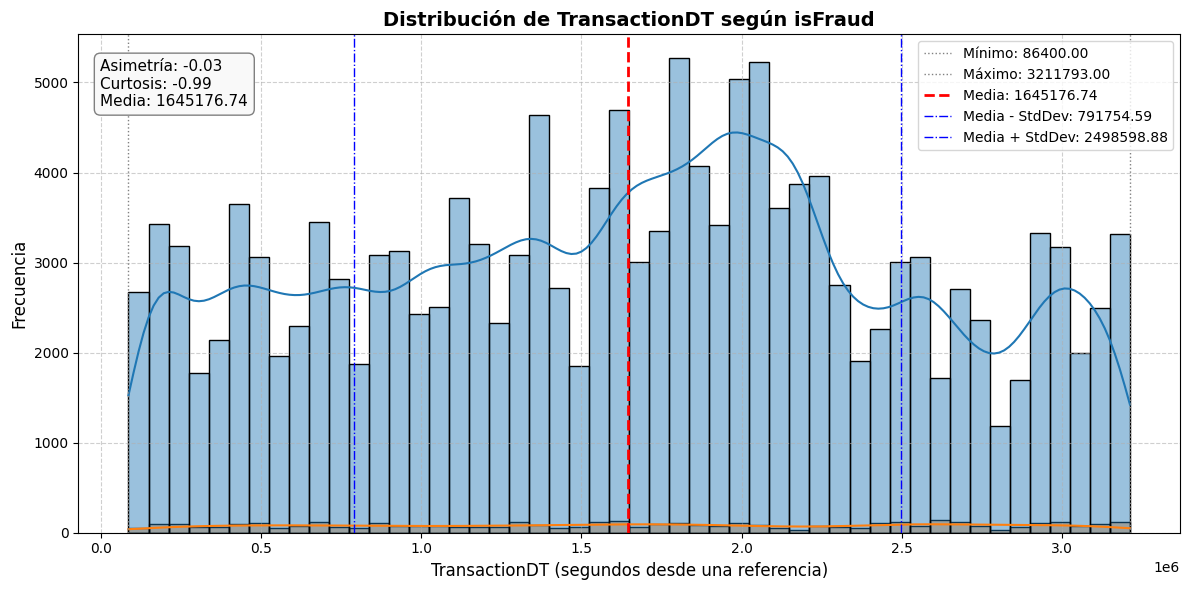

In [ ]:
# Variable temporal desde el dataset limpio
muestra_dt = df_clean['TransactionDT']

# Estadísticos
media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_clean,
    x='TransactionDT',
    hue='isFraud',
    bins=50,
    kde=True,
    multiple='layer',
    alpha=0.45
)

plt.axvline(np.min(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Mínimo: {np.min(muestra_dt):.2f}')
plt.axvline(np.max(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Máximo: {np.max(muestra_dt):.2f}')
plt.axvline(media_dt, color='red', linestyle='--', linewidth=2, label=f'Media: {media_dt:.2f}')

plt.axvline(media_dt - desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media - StdDev: {(media_dt - desviacion_estandar_dt):.2f}')
plt.axvline(media_dt + desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media + StdDev: {(media_dt + desviacion_estandar_dt):.2f}')

plt.title("Distribución de TransactionDT según isFraud", fontsize=14, fontweight='bold')
plt.xlabel("TransactionDT (segundos desde una referencia)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

plt.text(
    0.02, 0.95,
    f"Asimetría: {asimetria_dt:.2f}\nCurtosis: {curtosis_dt:.2f}\nMedia: {media_dt:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9", edgecolor="gray")
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

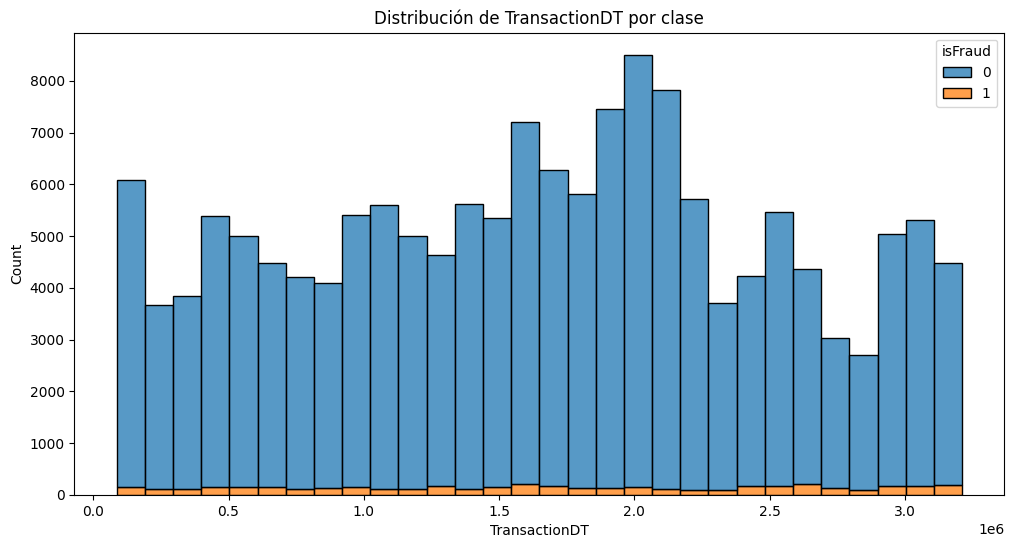

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(data=df_clean,x='TransactionDT',hue='isFraud',bins=30,multiple='stack')

plt.title('Distribución de TransactionDT por clase')
plt.show()

In [ ]:
df_clean['DT_bin'] = pd.qcut(df_clean['TransactionDT'],q=10,duplicates='drop')

tabla_dt = pd.crosstab(df_clean['DT_bin'],df_clean['isFraud'], normalize='index') * 100

tabla_dt

isFraud,0,1
DT_bin,,
"(86399.999, 424434.0]",97.279918,2.720082
"(424434.0, 771233.8]",97.009646,2.990354
"(771233.8, 1112601.1]",97.382637,2.617363
"(1112601.1, 1404011.4]",97.556427,2.443573
"(1404011.4, 1703424.0]",97.401929,2.598071
"(1703424.0, 1929211.0]",97.710611,2.289389
"(1929211.0, 2146273.4]",98.328082,1.671918
"(2146273.4, 2468198.8]",97.832797,2.167203
"(2468198.8, 2856452.5]",96.276527,3.723473


###Análisis Univariado de `TransactionAmt`

In [ ]:
from scipy.stats import skew, kurtosis

muestra_dt = df_clean['TransactionAmt']

media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

print(f"Media de TransactionAmt: {media_dt:.2f}")
print(f"Desviación Estándar de TransactionAmt: {desviacion_estandar_dt:.2f}")
print(f"Asimetría de TransactionAmt: {asimetria_dt:.2f}")
print(f"Curtosis de TransactionAmt: {curtosis_dt:.2f}")

Media de TransactionAmt: 128.34
Desviación Estándar de TransactionAmt: 200.94
Asimetría de TransactionAmt: 6.78
Curtosis de TransactionAmt: 70.78


In [ ]:
df_clean['Amt_bin'] = pd.qcut(df_clean['TransactionAmt'], q=10,duplicates='drop')

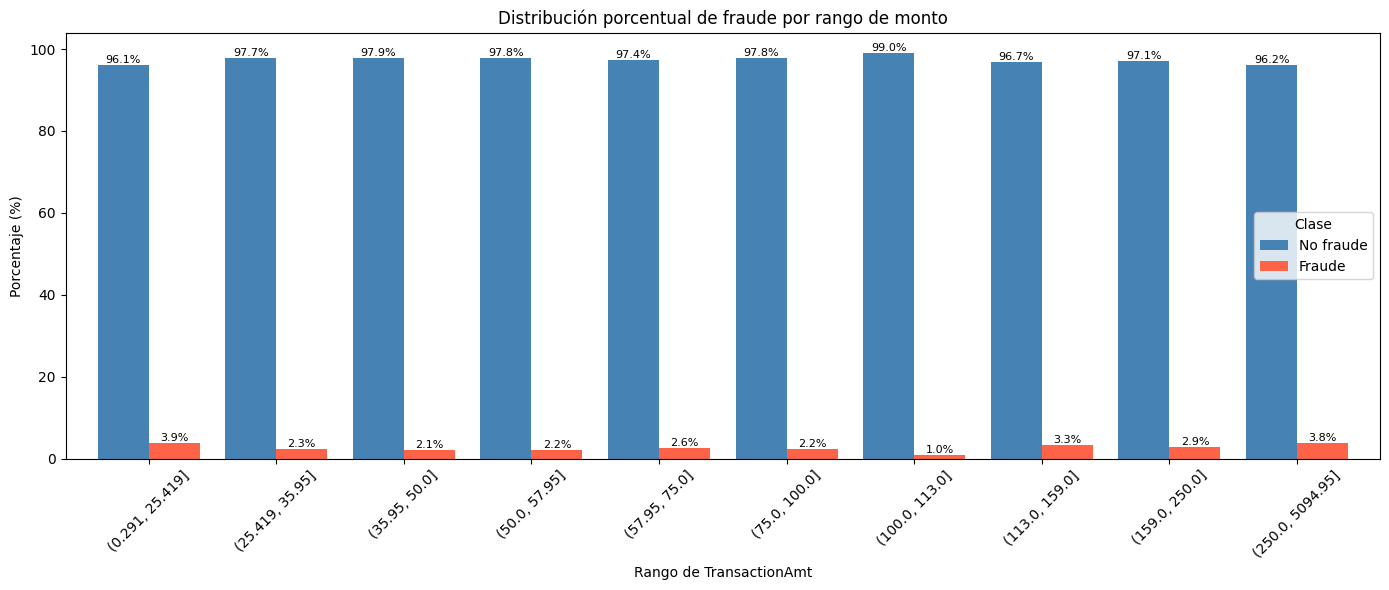

In [ ]:
tabla_amt = (
    pd.crosstab(
        df_clean['Amt_bin'],
        df_clean['isFraud'],
        normalize='index'
    ) * 100
)

tabla_amt.columns = ['No fraude', 'Fraude']

ax = tabla_amt.plot(
    kind='bar',
    figsize=(14,6),
    width=0.8,
    color=['steelblue','tomato']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('Distribución porcentual de fraude por rango de monto')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Rango de TransactionAmt')
plt.xticks(rotation=45)
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

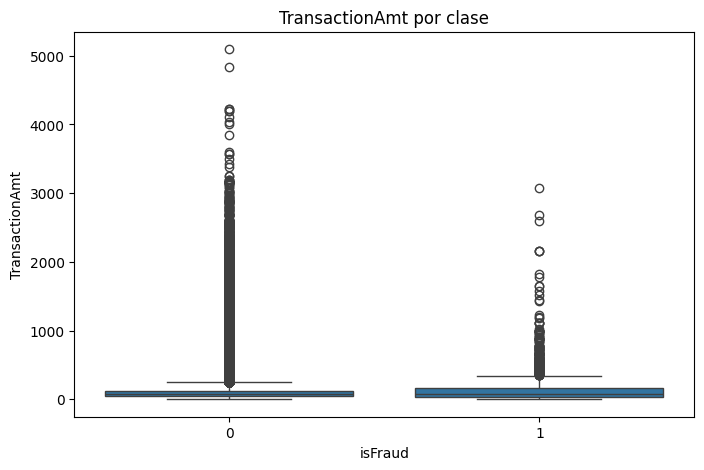

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x='isFraud', y='TransactionAmt')

plt.title('TransactionAmt por clase')
plt.show()

## Análisis bivariado

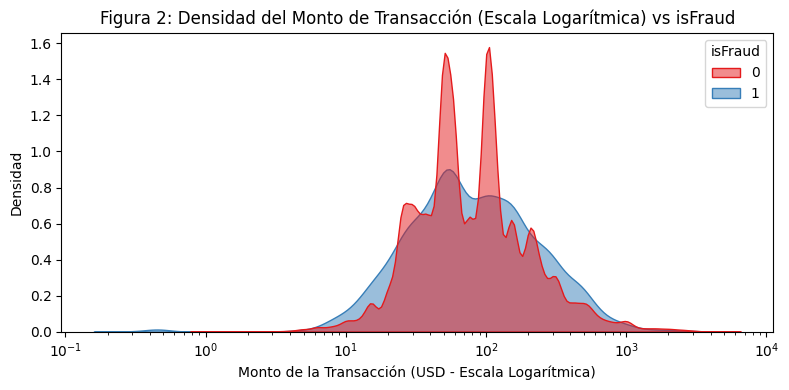

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='TransactionAmt', hue='isFraud', fill=True, common_norm=False, palette='Set1', log_scale=True, alpha=0.5)
plt.title('Figura 2: Densidad del Monto de Transacción (Escala Logarítmica) vs isFraud', fontsize=12)
plt.xlabel('Monto de la Transacción (USD - Escala Logarítmica)')
plt.ylabel('Densidad')
plt.tight_layout()
#plt.savefig('figura2_monto_density.png', dpi=300)
plt.show()

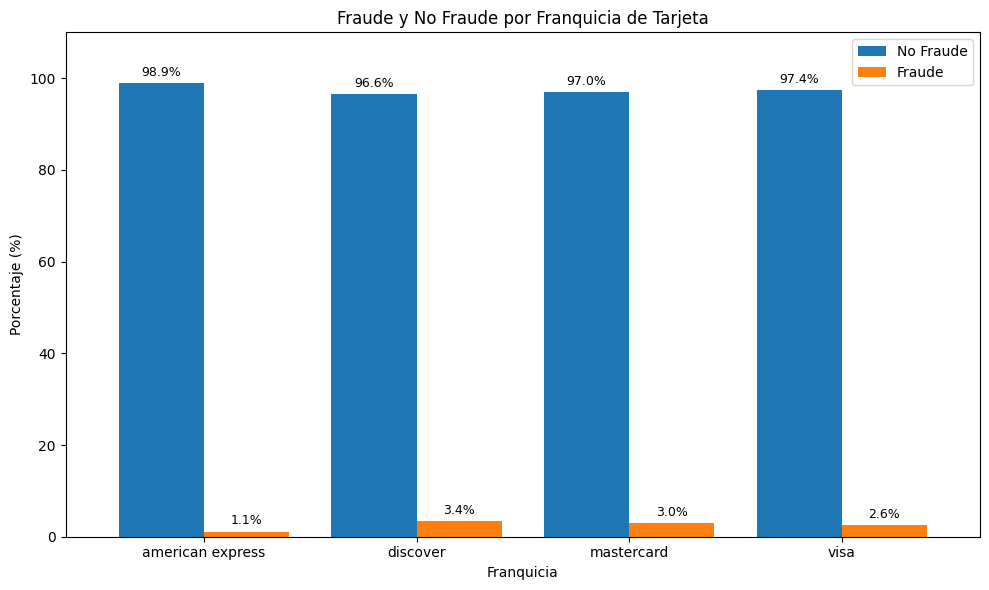

In [ ]:
# Porcentaje de fraude y no fraude por franquicia

tabla_card = (pd.crosstab(df_clean['card4'], df_clean['isFraud'], normalize='index') * 100)

ax = tabla_card.plot(kind='bar', figsize=(10,6),width=0.8)

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%', fontsize=9, padding=3)

plt.title('Fraude y No Fraude por Franquicia de Tarjeta')
plt.xlabel('Franquicia')
plt.ylabel('Porcentaje (%)')
plt.legend(['No Fraude', 'Fraude'])

plt.xticks(rotation=0)
plt.ylim(0, 110)

plt.tight_layout()
plt.show()

'MasterCard' (3.1%%) y 'Discover' (3.0%%) presentan proporciones de fraude ligeramente superiores en comparación con 'Visa' (2.51%) y 'American Express' (1.4%). Estas diferencias, aunque menores, podrían indicar variaciones en los métodos de seguridad o el perfil de riesgo asociado a cada franquicia.

In [ ]:
tabla_device = (pd.crosstab(df_clean['DeviceType'], df_clean['isFraud'], normalize='index') * 100)

display(tabla_device.round(2))

isFraud,0,1
DeviceType,,
desktop,97.01,2.99
mobile,94.55,5.45


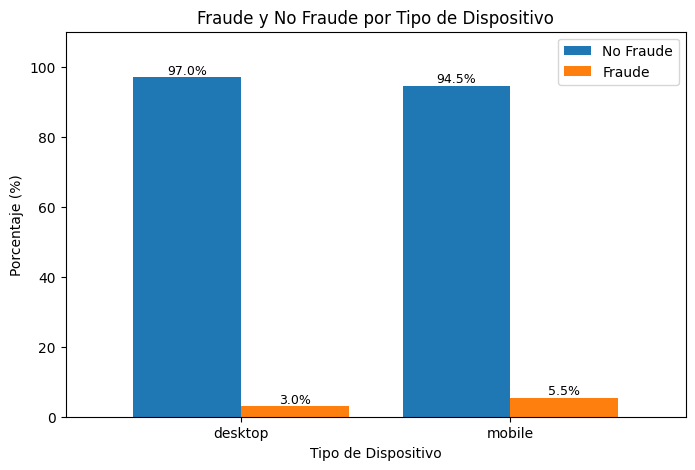

In [ ]:
ax = tabla_device.plot(kind='bar', figsize=(8,5), width=0.8)

for container in ax.containers:ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title('Fraude y No Fraude por Tipo de Dispositivo')
plt.xlabel('Tipo de Dispositivo')
plt.ylabel('Porcentaje (%)')
plt.legend(['No Fraude', 'Fraude'])

plt.xticks(rotation=0)
plt.ylim(0,110)

plt.show()



El gráfico de barras para la tasa de fraude por `DeviceType` revela
que los dispositivos móviles (`Mobile`) presentan una tasa de fraude considerablemente más alta que los dispositivos `Desktop`. Esto podría deberse a varios factores, como una menor seguridad en dispositivos móviles, la facilidad para realizar transacciones rápidas que pueden ser explotadas por estafadores, o patrones de uso que favorecen el fraude.



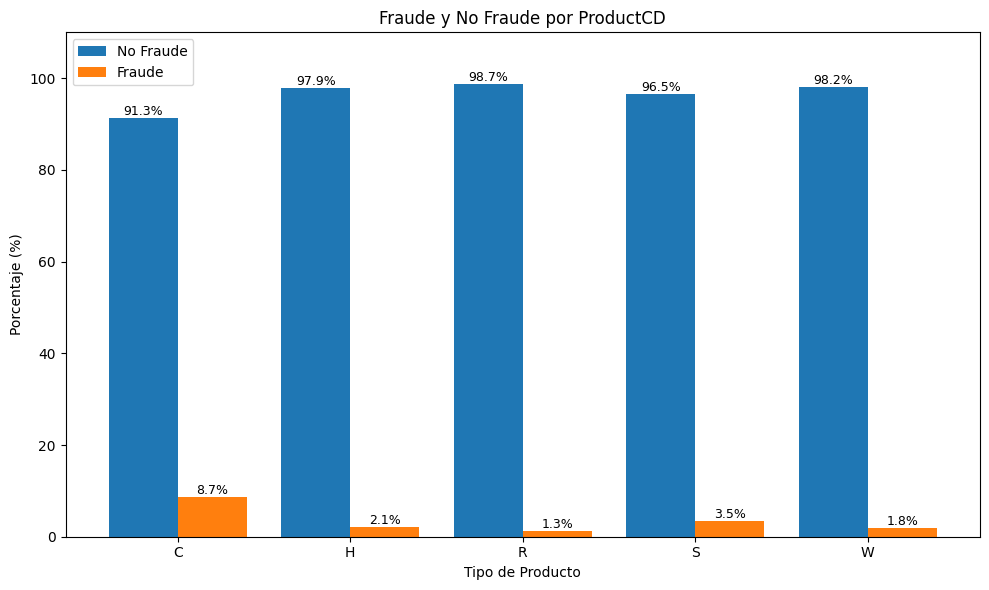

In [ ]:
tabla_prod = (pd.crosstab(df_clean['ProductCD'], df_clean['isFraud'], normalize='index') * 100)

ax = tabla_prod.plot(kind='bar', figsize=(10,6),width=0.8)

for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title('Fraude y No Fraude por ProductCD')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de Producto')

plt.legend(['No Fraude','Fraude'])

plt.xticks(rotation=0)
plt.ylim(0,110)

plt.tight_layout()
plt.show()

In [ ]:
tabla_card = (pd.crosstab(df_clean['ProductCD'],df_clean['isFraud'], normalize='index') * 100
)
display(tabla_card.round(2))

isFraud,0,1
ProductCD,,
C,91.29,8.71
H,97.89,2.11
R,98.70,1.30
S,96.51,3.49
W,98.17,1.83


Se observa una clara predominancia del fraude en ciertas categorías de productos. Por ejemplo, los códigos 'S' y 'C' muestran una cantidad significativa de transacciones fraudulentas, siendo la categoría 'C' particularmente crítica ya que un alto porcentaje de sus transacciones son fraude, indicando que el tipo de producto puede ser un factor discriminante fuerte.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Preparación de datos para la prueba de independencia
df_chi = df[['DeviceType', 'isFraud']].dropna()

print(f"Registros evaluados para la prueba: {len(df_chi)}")

# 1. Generación de la tabla de contingencia
tabla_contingencia = pd.crosstab(df_chi['DeviceType'], df_chi['isFraud'])
print("\n--- TABLA DE CONTINGENCIA ---")
print(tabla_contingencia)

# 2. Ejecución de la prueba Chi-cuadrado
chi2, p, dof, esperados = chi2_contingency(tabla_contingencia)

# 3. Cálculo de la V de Cramer para medir el tamaño del efecto
n = tabla_contingencia.sum().sum()
min_dimension = min(tabla_contingencia.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dimension))

print("\n--- RESULTADOS ESTADÍSTICOS ---")
print(f"Estadístico Chi-cuadrado (χ²): {chi2:.4f}")
print(f"P-valor: {p:.4e}")
print(f"V de Cramer: {v_cramer:.4f}")

# Interpretación de resultados
alpha = 0.05
if p < alpha:
    print("\nConclusión: Se rechaza H0. Existe una relación significativa entre el Tipo de Dispositivo y el Fraude.")
else:
    print("\nConclusión: No se rechaza H0. No hay evidencia de relación estadística.")

Registros evaluados para la prueba: 61044

--- TABLA DE CONTINGENCIA ---
isFraud         0     1
DeviceType             
desktop     37782  1165
mobile      20892  1205

--- RESULTADOS ESTADÍSTICOS ---
Estadístico Chi-cuadrado (χ²): 228.3362
P-valor: 1.3747e-51
V de Cramer: 0.0612

Conclusión: Se rechaza H0. Existe una relación significativa entre el Tipo de Dispositivo y el Fraude.


Se aplicó una prueba Chi-cuadrado de independencia para evaluar si el tipo de dispositivo está asociado con la ocurrencia de fraude. El p-valor obtenido fue extremadamente bajo, por lo que se rechaza la hipótesis nula y se concluye que existe una relación estadísticamente significativa entre DeviceType y isFraud.

##  Análisis multivariado

In [ ]:
numeric_cols = df_clean.select_dtypes(include=np.number)

corr_spearman = (numeric_cols.corr(method='spearman')['isFraud'].drop('isFraud'))

corr_spearman = corr_spearman.sort_values(key=abs, ascending=False)

top15 = corr_spearman.head(15)

display(top15)

,isFraud
V244,0.340103
V242,0.314055
V246,0.311993
V243,0.309369
V258,0.286120
V257,0.285168
V190,0.264492
V186,0.251073
V232,0.248147
V233,0.243824


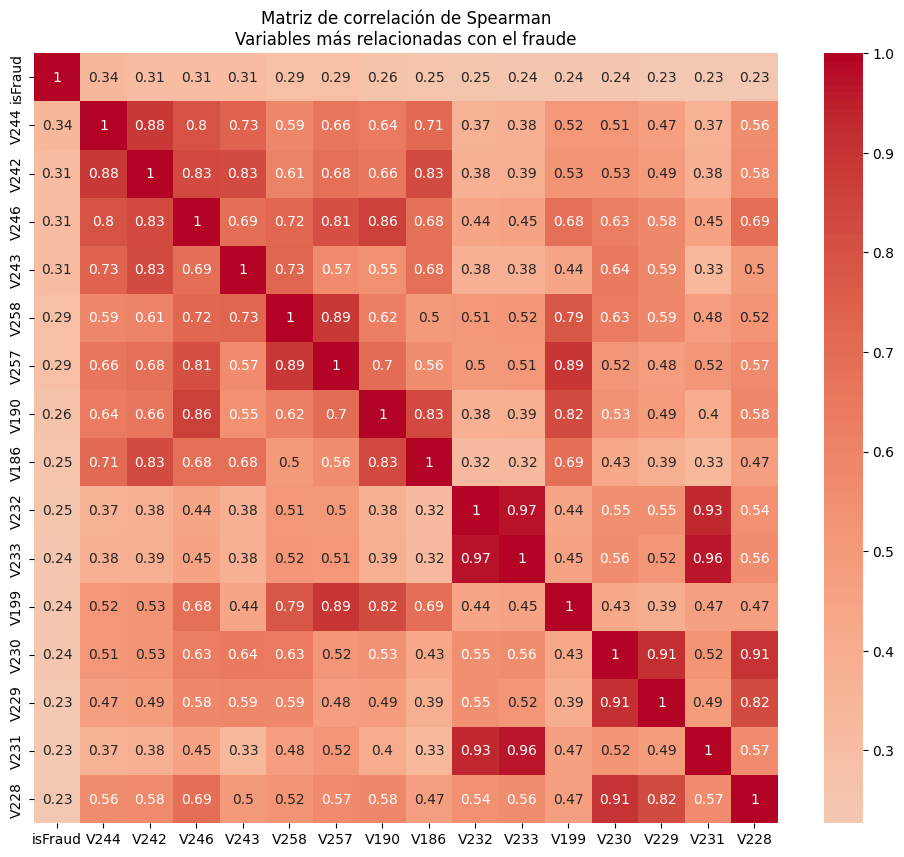

In [ ]:
variables_heatmap = ['isFraud'] + list(top15.index)

plt.figure(figsize=(12,10))

sns.heatmap(df_clean[variables_heatmap].corr(method='spearman') ,annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de correlación de Spearman\nVariables más relacionadas con el fraude')

plt.show()

### Codificación de Variables Categóricas (Label Encoding)

In [ ]:
# ==========================================
# Diagnóstico previo a la codificación
# ==========================================

cat_cols = df_clean.select_dtypes(include=['object']).columns

print(f"Número de variables categóricas: {len(cat_cols)}")

print("\nVariables categóricas encontradas:")
print(list(cat_cols))

print("\nEjemplo de categorías observadas:")

for col in ['ProductCD', 'card4', 'card6', 'DeviceType']:
    if col in df_clean.columns:
        print(f"\n{col}")
        print(df_clean[col].value_counts(dropna=False).head())

print("\nTipos de datos:")
display(df_clean[cat_cols].dtypes.to_frame('Tipo'))

Número de variables categóricas: 31

Ejemplo de valores en variables clave:
ProductCD: ['W' 'H' 'C' 'S' 'R']
card4: ['discover' 'mastercard' 'visa' 'american express' 'Unknown']
card6: ['credit' 'debit' 'Unknown' 'debit or credit' 'charge card']
DeviceType: ['Unknown' 'mobile' 'desktop']

Tipos de datos actuales:


,0
ProductCD,object
card4,object
card6,object
P_emaildomain,object
R_emaildomain,object
M1,object
M2,object
M3,object
M4,object
M5,object


In [ ]:
from sklearn.preprocessing import LabelEncoder

print("--- INICIANDO CODIFICACIÓN DE CATEGORÍAS ---")

cat_cols = df_clean.select_dtypes(include=['object']).columns

encoders = {}

for col in cat_cols:

    encoder = LabelEncoder()

    df_clean[col] = encoder.fit_transform(
        df_clean[col].astype(str)
    )

    encoders[col] = encoder

print(f"Codificación completada. {len(cat_cols)} variables transformadas.")
print(f"Dimensiones finales del dataset: {df_clean.shape}")

print("\nDistribución de tipos de datos:")
print(df_clean.dtypes.value_counts())

print("\nVerificación de columnas codificadas:")
display(df_clean[cat_cols].head())

--- INICIANDO CODIFICACIÓN DE CATEGORÍAS ---
Codificación completada. 31 variables transformadas.
Dimensiones finales del dataset: (155504, 309)

Distribución de tipos de datos:
float64     272
int64        35
category      1
category      1
Name: count, dtype: int64

Verificación de columnas codificadas:


,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,4,1,1,32,32,1,1,1,2,0,...,66,71,149,4,2,2,2,2,2,1085
1,4,2,1,16,32,2,2,2,0,1,...,66,71,149,4,2,2,2,2,2,1085
2,4,4,2,36,32,1,1,1,0,0,...,66,71,149,4,2,2,2,2,2,1085
3,4,2,2,54,32,2,2,2,0,1,...,66,71,149,4,2,2,2,2,2,1085
4,1,2,1,16,32,2,2,2,3,2,...,7,84,88,3,1,0,1,1,1,568


In [ ]:
print("\nVariables categóricas restantes:")

cat_restantes = df_clean.select_dtypes(include=['object']).columns

print(len(cat_restantes))

if len(cat_restantes) == 0:
    print("✓ Todas las variables categóricas fueron codificadas correctamente.")
else:
    print(cat_restantes)


Variables categóricas restantes:
0
✓ Todas las variables categóricas fueron codificadas correctamente.


### Exportación del Dataset Final

In [ ]:
print("===== AUDITORÍA FINAL DEL DATASET =====")

print(f"Dimensiones: {df_clean.shape}")

print(f"Nulos remanentes: {df_clean.isnull().sum().sum()}")

print(f"Variables categóricas restantes: {len(df_clean.select_dtypes(include=['object']).columns)}")

print("\nDistribución de la variable objetivo:")
print(df_clean['isFraud'].value_counts())

print("\nPorcentaje de fraude:")
print((df_clean['isFraud'].value_counts(normalize=True)*100).round(2))

===== AUDITORÍA FINAL DEL DATASET =====
Dimensiones: (155504, 309)
Nulos remanentes: 12501106
Variables categóricas restantes: 0

Distribución de la variable objetivo:
isFraud
0    151332
1      4172
Name: count, dtype: int64

Porcentaje de fraude:
isFraud
0    97.32
1     2.68
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# Exportación del dataset preprocesado
# ==========================================

nombre_archivo = 'train_final_preprocessed.csv'

df_clean.to_csv(nombre_archivo, index=False)

print("=== EXPORTACIÓN EXITOSA ===")
print(f"Archivo guardado: {nombre_archivo}")
print(f"Registros: {df_clean.shape[0]}")
print(f"Variables: {df_clean.shape[1]}")

=== EXPORTACIÓN EXITOSA ===
Archivo guardado: train_final_preprocessed.csv
Registros: 155504
Variables: 309


# Etapa de modelado

## Configuración Inicial y Carga de Datos

Importar todas las librerías necesarias, establecer la semilla de reproducibilidad, cargar el dataset 'train_final_preprocessed2.csv', y definir las variables X (características) y Y (variable objetivo 'isFraud').


In [ ]:
pip_packages = ['imblearn', 'umap-learn']

for package in pip_packages:
    try:
        __import__(package.replace('-', '_')) # Try importing to check if installed
        print(f"{package} is already installed.")
    except ImportError:
        print(f"Installing {package}...")
        !pip install {package}
        print(f"{package} installed successfully.")

imblearn is already installed.
Installing umap-learn...
umap-learn installed successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             auc, average_precision_score, f1_score, recall_score, precision_score)
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

# Imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
import xgboost as xgb

# UMAP
import umap

# Ignore warnings
warnings.filterwarnings('ignore')

# Establecer la semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Libraries imported and SEED set to 42.")

Libraries imported and SEED set to 42.


In [ ]:
df_final = pd.read_csv('train_final_preprocessed2.csv')

# Definir X (características) y Y (variable objetivo)
X = df_final.drop(columns=['isFraud', 'TransactionID'], errors='ignore') # 'errors=ignore' para evitar error si 'TransactionID' ya no existe
y = df_final['isFraud']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (106239, 633)
Shape of y: (106239,)


## División de Datos (Train/Test)

Se divide el dataset en conjuntos de entrenamiento y prueba, reservando el conjunto de prueba para la evaluación final.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (84991, 633)
Shape of X_test: (21248, 633)
Shape of y_train: (84991,)
Shape of y_test: (21248,)


## Auditoría de Características: Varianza y Correlación

Se calcula y muestra el número de variables y registros. Identificar y eliminar variables con varianza cercana a cero. Construir una matriz de correlación e identificar pares de variables con correlación absoluta > 0.95, eliminando una de cada par para reducir la redundancia.


In [ ]:
print(f"Número de registros en X_train: {X_train.shape[0]}")
print(f"Número de variables en X_train: {X_train.shape[1]}")

Número de registros en X_train: 84991
Número de variables en X_train: 633


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Identificar variables con varianza cercana a cero
# Se usa un threshold de 0.01 para remover características con varianza muy baja.
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

# Obtener las columnas con baja varianza a eliminar
low_variance_cols = X_train.columns[~selector.get_support()]

print(f"Número de variables con varianza cercana a cero: {len(low_variance_cols)}")
print(f"Variables con varianza cercana a cero: {list(low_variance_cols)[:10]}...") # Muestra las primeras 10

# Eliminar estas columnas de X_train y X_test
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

# Volver a convertir a DataFrame para mantener los nombres de las columnas
X_train = pd.DataFrame(X_train, columns=selector.get_feature_names_out())
X_test = pd.DataFrame(X_test, columns=selector.get_feature_names_out())

print(f"\nNueva forma de X_train después de eliminar variables de baja varianza: {X_train.shape}")
print(f"Nueva forma de X_test después de eliminar variables de baja varianza: {X_test.shape}")

Número de variables con varianza cercana a cero: 118
Variables con varianza cercana a cero: ['V1', 'V2', 'V6', 'V8', 'V9', 'V14', 'V27', 'V28', 'V41', 'V65']...

Nueva forma de X_train después de eliminar variables de baja varianza: (84991, 515)
Nueva forma de X_test después de eliminar variables de baja varianza: (21248, 515)


In [ ]:
import numpy as np

# Construir la matriz de correlación
corr_matrix = X_train.corr().abs()

# Seleccionar el triángulo superior de la matriz de correlación para evitar duplicados
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontrar las columnas con correlación superior a 0.95
to_drop_high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Número de variables con correlación absoluta > 0.95: {len(to_drop_high_corr)}")
print(f"Variables a eliminar por alta correlación: {to_drop_high_corr[:10]}...") # Muestra las primeras 10

# Eliminar las columnas identificadas de X_train y X_test
X_train = X_train.drop(columns=to_drop_high_corr)
X_test = X_test.drop(columns=to_drop_high_corr)

print(f"\nNueva forma de X_train después de eliminar variables altamente correlacionadas: {X_train.shape}")
print(f"Nueva forma de X_test después de eliminar variables altamente correlacionadas: {X_test.shape}")

Número de variables con correlación absoluta > 0.95: 276
Variables a eliminar por alta correlación: ['C2', 'C4', 'C6', 'C7', 'C8', 'C10', 'C11', 'C12', 'C14', 'D2']...

Nueva forma de X_train después de eliminar variables altamente correlacionadas: (84991, 239)
Nueva forma de X_test después de eliminar variables altamente correlacionadas: (21248, 239)


## Selección Inicial de Características

Se aplican tres métodos de selección de características: Mutual Information, Random Forest y XGBoost. Después, se combinan los rankings de estos tres métodos para crear un ranking consolidado de importancia de características.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 2. Entrenar RandomForestClassifier para obtener feature_importances_
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
rf_model.fit(X_train, y_train)

rf_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_Importance': rf_model.feature_importances_
})
rf_df = rf_df.sort_values(by='RF_Importance', ascending=False)

print("Top 10 features by Random Forest Importance:")
display(rf_df.head(10))

# 3. Entrenar XGBClassifier para extraer importancia
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED
)
xgb_model.fit(X_train, y_train)

xgb_df = pd.DataFrame({
    'Feature': X_train.columns,
    'XGB_Importance': xgb_model.feature_importances_
})
xgb_df = xgb_df.sort_values(by='XGB_Importance', ascending=False)

print("\nTop 10 features by XGBoost Importance:")
display(xgb_df.head(10))

# Combine the rankings
mi_df['MI_Rank'] = mi_df['MI_Score'].rank(ascending=False)
rf_df['RF_Rank'] = rf_df['RF_Importance'].rank(ascending=False)
xgb_df['XGB_Rank'] = xgb_df['XGB_Importance'].rank(ascending=False)

combined_df = mi_df.merge(rf_df, on='Feature', how='left')
combined_df = combined_df.merge(xgb_df, on='Feature', how='left')

combined_df['Combined_Rank'] = combined_df[['MI_Rank', 'RF_Rank', 'XGB_Rank']].mean(axis=1)

consolidated_rank = combined_df.sort_values(by='Combined_Rank', ascending=True)

print("\nTop 20 features by Consolidated Rank:")
display(consolidated_rank.head(20))

Top 10 features by Random Forest Importance:


,Feature,RF_Importance
138,V201,0.046538
133,V189,0.038923
13,C1,0.032093
59,V45,0.031751
132,V188,0.026289
136,V198,0.025714
147,V245,0.024285
137,V200,0.023134
153,V257,0.022836
87,V87,0.021944



Top 10 features by XGBoost Importance:


,Feature,XGB_Importance
138,V201,0.253004
97,V102,0.061762
231,M4_was_null,0.042971
124,V148,0.037396
59,V45,0.030218
147,V245,0.027697
149,V247,0.025232
136,V198,0.017527
187,V318,0.016053
170,V296,0.013582



Top 20 features by Consolidated Rank:


,Feature,MI_Score,MI_Rank,RF_Importance,RF_Rank,XGB_Importance,XGB_Rank,Combined_Rank
0,V201,0.034241,1.0,0.046538,1.0,0.253004,1.0,1.000000
5,V45,0.026863,6.0,0.031751,4.0,0.030218,5.0,5.000000
6,V198,0.026794,7.0,0.025714,6.0,0.017527,8.0,7.000000
7,V246,0.026776,8.0,0.017522,11.0,0.003896,40.0,19.666667
49,V245,0.020066,50.0,0.024285,7.0,0.027697,6.0,21.000000
46,V148,0.020317,47.0,0.012266,15.0,0.037396,4.0,22.000000
14,id_17,0.024478,15.0,0.010176,20.0,0.003765,42.0,25.666667
11,V67,0.025254,12.0,0.005488,47.0,0.008116,20.0,26.333333
4,V189,0.027063,5.0,0.038923,2.0,0.002274,73.0,26.666667
34,V87,0.021621,35.0,0.021944,10.0,0.003441,44.0,29.666667


## Creación de subconjuntos de caracteristicas

Se generan varios subconjuntos de características utilizando diferentes umbrales de las N características principales (por ejemplo, las 20, 50 o 100 características principales)

In [ ]:
all_features_ranked = consolidated_rank['Feature'].tolist()

print(f"Total ranked features: {len(all_features_ranked)}")
print("First 10 ranked features:")
print(all_features_ranked[:10])

Total ranked features: 239
First 10 ranked features:
['V201', 'V45', 'V198', 'V246', 'V245', 'V148', 'id_17', 'V67', 'V189', 'V87']


In [ ]:
top_n_thresholds = [20, 50, 100, 150, 200, len(all_features_ranked)]

feature_subsets = {}

for n in top_n_thresholds:
    subset_name = f'top_{n}_features'
    feature_subsets[subset_name] = all_features_ranked[:n]
    print(f"Subset '{subset_name}' created with {len(feature_subsets[subset_name])} features.")

print("\nExample of 'top_20_features':")
print(feature_subsets['top_20_features'])


Subset 'top_20_features' created with 20 features.
Subset 'top_50_features' created with 50 features.
Subset 'top_100_features' created with 100 features.
Subset 'top_150_features' created with 150 features.
Subset 'top_200_features' created with 200 features.
Subset 'top_239_features' created with 239 features.

Example of 'top_20_features':
['V201', 'V45', 'V198', 'V246', 'V245', 'V148', 'id_17', 'V67', 'V189', 'V87', 'card3', 'V78', 'V247', 'card1', 'ProductCD', 'V157', 'M4_was_null', 'C1', 'V53', 'V123']


## Entrenamiento y evaluación de modelos ligeros

Se entrena y evalúa dos modelos de clasificación ligeros (regresión logística y árbol de decisión) en cada subconjunto de características creado en el paso anterior. Se evalúa su rendimiento utilizando métricas adecuadas para la clasificación desequilibrada.


In [ ]:
lr_metrics = {}
dt_metrics = {}

print("Initialized dictionaries to store Logistic Regression and Decision Tree metrics.")

Initialized dictionaries to store Logistic Regression and Decision Tree metrics.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline # Using imblearn.pipeline to integrate SMOTE if needed later, or just for clarity


for subset_name, features in feature_subsets.items():
    print(f"\nEvaluating on {subset_name} with {len(features)} features...")

    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    # ===============================
    # Logistic Regression
    # ===============================
    # Using a pipeline for scaling for Logistic Regression
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=SEED, solver='liblinear', class_weight='balanced', max_iter=1000))
    ])

    lr_pipeline.fit(X_train_subset, y_train)
    lr_preds = lr_pipeline.predict(X_test_subset)
    lr_proba = lr_pipeline.predict_proba(X_test_subset)[:, 1]

    lr_roc_auc = roc_auc_score(y_test, lr_proba)
    lr_f1 = f1_score(y_test, lr_preds)
    lr_metrics[subset_name] = {'roc_auc': lr_roc_auc, 'f1_score': lr_f1}
    print(f"  Logistic Regression - ROC-AUC: {lr_roc_auc:.4f}, F1-Score: {lr_f1:.4f}")

    # ===============================
    # Decision Tree
    # ===============================
    # Decision Tree does not require scaling
    dt_model = DecisionTreeClassifier(random_state=SEED, class_weight='balanced', max_depth=10)
    dt_model.fit(X_train_subset, y_train)
    dt_preds = dt_model.predict(X_test_subset)
    dt_proba = dt_model.predict_proba(X_test_subset)[:, 1]

    dt_roc_auc = roc_auc_score(y_test, dt_proba)
    dt_f1 = f1_score(y_test, dt_preds)
    dt_metrics[subset_name] = {'roc_auc': dt_roc_auc, 'f1_score': dt_f1}
    print(f"  Decision Tree - ROC-AUC: {dt_roc_auc:.4f}, F1-Score: {dt_f1:.4f}")

print("\nFinished training and evaluating lightweight models on all feature subsets.")


Evaluating on top_20_features with 20 features...
  Logistic Regression - ROC-AUC: 0.8020, F1-Score: 0.1159
  Decision Tree - ROC-AUC: 0.8192, F1-Score: 0.2628

Evaluating on top_50_features with 50 features...
  Logistic Regression - ROC-AUC: 0.8377, F1-Score: 0.1513
  Decision Tree - ROC-AUC: 0.8577, F1-Score: 0.2284

Evaluating on top_100_features with 100 features...
  Logistic Regression - ROC-AUC: 0.8583, F1-Score: 0.1686
  Decision Tree - ROC-AUC: 0.8360, F1-Score: 0.2747

Evaluating on top_150_features with 150 features...
  Logistic Regression - ROC-AUC: 0.8636, F1-Score: 0.1777
  Decision Tree - ROC-AUC: 0.8643, F1-Score: 0.2411

Evaluating on top_200_features with 200 features...
  Logistic Regression - ROC-AUC: 0.8671, F1-Score: 0.1830
  Decision Tree - ROC-AUC: 0.8663, F1-Score: 0.2445

Evaluating on top_239_features with 239 features...
  Logistic Regression - ROC-AUC: 0.8712, F1-Score: 0.1864
  Decision Tree - ROC-AUC: 0.8640, F1-Score: 0.2421

Finished training and eva

### Visualización de los Resultados y Selección del Conjunto Óptimo de Características

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir los diccionarios de métricas a DataFrames
lr_results_df = pd.DataFrame.from_dict(lr_metrics, orient='index')
dt_results_df = pd.DataFrame.from_dict(dt_metrics, orient='index')

# Añadir una columna con el número de características
lr_results_df['num_features'] = [int(s.split('_')[1]) for s in lr_results_df.index]
dt_results_df['num_features'] = [int(s.split('_')[1]) for s in dt_results_df.index]

# Ordenar por número de características
lr_results_df = lr_results_df.sort_values(by='num_features')
dt_results_df = dt_results_df.sort_values(by='num_features')

print("Resultados de Logistic Regression:")
display(lr_results_df)

print("\nResultados de Decision Tree:")
display(dt_results_df)

Resultados de Logistic Regression:


,roc_auc,f1_score,num_features
top_20_features,0.802050,0.115911,20
top_50_features,0.837715,0.151325,50
top_100_features,0.858339,0.168584,100
top_150_features,0.863601,0.177710,150
top_200_features,0.867096,0.183027,200
top_239_features,0.871249,0.186437,239



Resultados de Decision Tree:


,roc_auc,f1_score,num_features
top_20_features,0.819187,0.262755,20
top_50_features,0.857695,0.228397,50
top_100_features,0.835982,0.274749,100
top_150_features,0.864280,0.241118,150
top_200_features,0.866309,0.244497,200
top_239_features,0.864028,0.242102,239


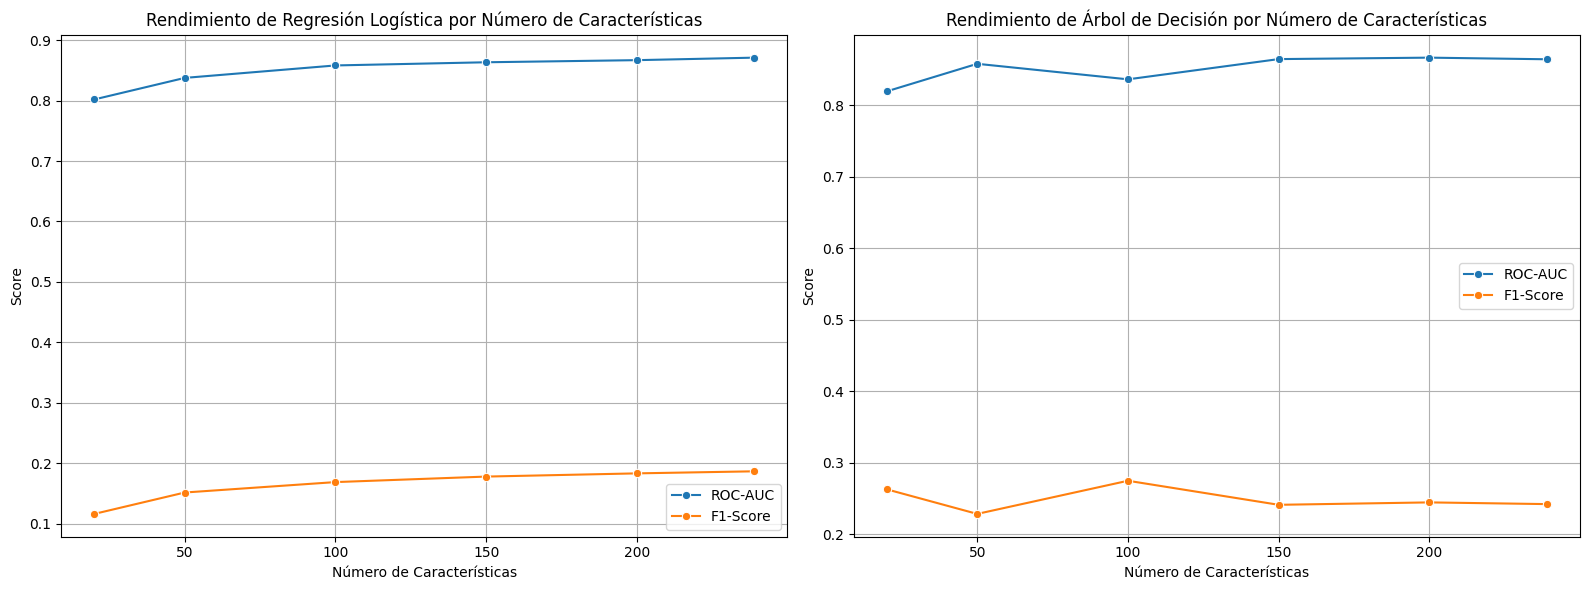


Mejor subconjunto para Regresión Logística (ROC-AUC): top_239_features con 239.0 características (ROC-AUC: 0.8712)
Mejor subconjunto para Árbol de Decisión (ROC-AUC): top_200_features con 200.0 características (ROC-AUC: 0.8663)

Se ha seleccionado el conjunto óptimo de características reducido 'top_239_features' con 239 características.
Dimensiones de X_reduced: (84991, 239)
Stored selected features in 'X_final_features': 239 features


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot para Logistic Regression
sns.lineplot(ax=axes[0], x='num_features', y='roc_auc', data=lr_results_df, marker='o', label='ROC-AUC')
sns.lineplot(ax=axes[0], x='num_features', y='f1_score', data=lr_results_df, marker='o', label='F1-Score')
axes[0].set_title('Rendimiento de Regresión Logística por Número de Características')
axes[0].set_xlabel('Número de Características')
axes[0].set_ylabel('Score')
axes[0].grid(True)
axes[0].legend()

# Plot para Decision Tree
sns.lineplot(ax=axes[1], x='num_features', y='roc_auc', data=dt_results_df, marker='o', label='ROC-AUC')
sns.lineplot(ax=axes[1], x='num_features', y='f1_score', data=dt_results_df, marker='o', label='F1-Score')
axes[1].set_title('Rendimiento de Árbol de Decisión por Número de Características')
axes[1].set_xlabel('Número de Características')
axes[1].set_ylabel('Score')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Identificar el mejor subconjunto de características basado en ROC-AUC para LR
best_lr_roc_auc_subset = lr_results_df.loc[lr_results_df['roc_auc'].idxmax()]
print(f"\nMejor subconjunto para Regresión Logística (ROC-AUC): {best_lr_roc_auc_subset.name} con {best_lr_roc_auc_subset['num_features']} características (ROC-AUC: {best_lr_roc_auc_subset['roc_auc']:.4f})")

# Identificar el mejor subconjunto de características basado en ROC-AUC para DT
best_dt_roc_auc_subset = dt_results_df.loc[dt_results_df['roc_auc'].idxmax()]
print(f"Mejor subconjunto para Árbol de Decisión (ROC-AUC): {best_dt_roc_auc_subset.name} con {best_dt_roc_auc_subset['num_features']} características (ROC-AUC: {best_dt_roc_auc_subset['roc_auc']:.4f})")

# Selecting the optimal reduced feature set (example: using the best for LR, but could be adapted)
# For this example, let's pick the 'top_239_features' as it gave the best ROC-AUC for LR
X_reduced_features_name = best_lr_roc_auc_subset.name
X_reduced = X_train[feature_subsets[X_reduced_features_name]]

print(f"\nSe ha seleccionado el conjunto óptimo de características reducido '{X_reduced_features_name}' con {len(X_reduced.columns)} características.")
print(f"Dimensiones de X_reduced: {X_reduced.shape}")

# Store the selected features in a new variable 'X_final_features'
X_final_features = feature_subsets[X_reduced_features_name]
print(f"Stored selected features in 'X_final_features': {len(X_final_features)} features")

## Entrenamiento Completo de Modelos


Se entrena diversos modelos de Machine Learning (Regresión Logística, Árbol de Decisión, Random Forest, XGBoost, MLPClassifier, SVC) en el conjunto de características reducido (`X_final_features`).

In [ ]:
X_train_final = X_train[X_final_features]
X_test_final = X_test[X_final_features]

print(f"Shape of X_train_final: {X_train_final.shape}")
print(f"Shape of X_test_final: {X_test_final.shape}")

Shape of X_train_final: (84991, 239)
Shape of X_test_final: (21248, 239)


### Entrenamiento y Evaluación de Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, average_precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline

print("---- ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN LOGÍSTICA ----")

# Pipeline para Regresión Logística con escalado y manejo de desbalance de clases
# Utilizaremos SMOTE para balancear las clases en el conjunto de entrenamiento
# y StandardScaler para escalar las características.

lr_pipeline_full = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)), # Aplicar SMOTE en el entrenamiento
    ('model', LogisticRegression(
        random_state=SEED,
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000
    ))
])

# Entrenar el modelo
lr_pipeline_full.fit(X_train_final, y_train)

# Predicciones en el conjunto de prueba
lr_preds_full = lr_pipeline_full.predict(X_test_final)
lr_proba_full = lr_pipeline_full.predict_proba(X_test_final)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (Logistic Regression):")
print(classification_report(y_test, lr_preds_full))

roc_auc_full = roc_auc_score(y_test, lr_proba_full)
pr_auc_full = average_precision_score(y_test, lr_proba_full)

print(f"ROC-AUC (Logistic Regression): {roc_auc_full:.4f}")
print(f"PR-AUC (Logistic Regression): {pr_auc_full:.4f}")

# Almacenar métricas para comparación futura
model_performance = {}
model_performance['LogisticRegression'] = {
    'roc_auc': roc_auc_full,
    'pr_auc': pr_auc_full,
    'report': classification_report(y_test, lr_preds_full, output_dict=True)
}

print("\nRegresión Logística entrenada y evaluada.")

---- ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN LOGÍSTICA ----

Reporte de Clasificación (Logistic Regression):
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     20713
           1       0.10      0.76      0.17       535

    accuracy                           0.82     21248
   macro avg       0.54      0.79      0.53     21248
weighted avg       0.97      0.82      0.88     21248

ROC-AUC (Logistic Regression): 0.8651
PR-AUC (Logistic Regression): 0.3532

Regresión Logística entrenada y evaluada.


### Entrenamiento y Evaluación de Árbol de Decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

print("---- ENTRENAMIENTO Y EVALUACIÓN DE ÁRBOL DE DECISIÓN ----")

dt_model_full = DecisionTreeClassifier(
    random_state=SEED,
    class_weight='balanced',
    max_depth=10 # Limitar la profundidad para evitar sobreajuste y agilizar el entrenamiento
)

# Entrenar el modelo
dt_model_full.fit(X_train_final, y_train)

# Predicciones en el conjunto de prueba
dt_preds_full = dt_model_full.predict(X_test_final)
dt_proba_full = dt_model_full.predict_proba(X_test_final)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (Decision Tree):")
print(classification_report(y_test, dt_preds_full))

roc_auc_full_dt = roc_auc_score(y_test, dt_proba_full)
pr_auc_full_dt = average_precision_score(y_test, dt_proba_full)

print(f"ROC-AUC (Decision Tree): {roc_auc_full_dt:.4f}")
print(f"PR-AUC (Decision Tree): {pr_auc_full_dt:.4f}")

# Almacenar métricas para comparación futura
model_performance['DecisionTree'] = {
    'roc_auc': roc_auc_full_dt,
    'pr_auc': pr_auc_full_dt,
    'report': classification_report(y_test, dt_preds_full, output_dict=True)
}

print("\nÁrbol de Decisión entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE ÁRBOL DE DECISIÓN ----

Reporte de Clasificación (Decision Tree):
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     20713
           1       0.14      0.77      0.24       535

    accuracy                           0.88     21248
   macro avg       0.57      0.82      0.59     21248
weighted avg       0.97      0.88      0.92     21248

ROC-AUC (Decision Tree): 0.8640
PR-AUC (Decision Tree): 0.3810

Árbol de Decisión entrenado y evaluado.


### Entrenamiento y Evaluación de Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("---- ENTRENAMIENTO Y EVALUACIÓN DE RANDOM FOREST ----")

rf_model_full = RandomForestClassifier(
    random_state=SEED,
    class_weight='balanced',
    n_estimators=100,
    max_depth=10
)

# Entrenar el modelo
rf_model_full.fit(X_train_final, y_train)

# Predicciones en el conjunto de prueba
rf_preds_full = rf_model_full.predict(X_test_final)
rf_proba_full = rf_model_full.predict_proba(X_test_final)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (Random Forest):")
print(classification_report(y_test, rf_preds_full))

roc_auc_full_rf = roc_auc_score(y_test, rf_proba_full)
pr_auc_full_rf = average_precision_score(y_test, rf_proba_full)

print(f"ROC-AUC (Random Forest): {roc_auc_full_rf:.4f}")
print(f"PR-AUC (Random Forest): {pr_auc_full_rf:.4f}")

# Almacenar métricas para comparación futura
model_performance['RandomForest'] = {
    'roc_auc': roc_auc_full_rf,
    'pr_auc': pr_auc_full_rf,
    'report': classification_report(y_test, rf_preds_full, output_dict=True)
}

print("\nRandom Forest entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE RANDOM FOREST ----

Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     20713
           1       0.19      0.72      0.31       535

    accuracy                           0.92     21248
   macro avg       0.59      0.82      0.63     21248
weighted avg       0.97      0.92      0.94     21248

ROC-AUC (Random Forest): 0.8958
PR-AUC (Random Forest): 0.5174

Random Forest entrenado y evaluado.


### Entrenamiento y Evaluación de XGBoost

In [ ]:
import xgboost as xgb

print("---- ENTRENAMIENTO Y EVALUACIÓN DE XGBoost ----")

xgb_model_full = xgb.XGBClassifier(
    random_state=SEED,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(), # Para manejar el desbalance de clases
    n_estimators=100,
    max_depth=6 # Limitar la profundidad para evitar sobreajuste y agilizar el entrenamiento
)

# Entrenar el modelo
xgb_model_full.fit(X_train_final, y_train)

# Predicciones en el conjunto de prueba
xgb_preds_full = xgb_model_full.predict(X_test_final)
xgb_proba_full = xgb_model_full.predict_proba(X_test_final)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (XGBoost):")
print(classification_report(y_test, xgb_preds_full))

roc_auc_full_xgb = roc_auc_score(y_test, xgb_proba_full)
pr_auc_full_xgb = average_precision_score(y_test, xgb_proba_full)

print(f"ROC-AUC (XGBoost): {roc_auc_full_xgb:.4f}")
print(f"PR-AUC (XGBoost): {pr_auc_full_xgb:.4f}")

# Almacenar métricas para comparación futura
model_performance['XGBoost'] = {
    'roc_auc': roc_auc_full_xgb,
    'pr_auc': pr_auc_full_xgb,
    'report': classification_report(y_test, xgb_preds_full, output_dict=True)
}

print("\nXGBoost entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE XGBoost ----

Reporte de Clasificación (XGBoost):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     20713
           1       0.36      0.74      0.48       535

    accuracy                           0.96     21248
   macro avg       0.68      0.85      0.73     21248
weighted avg       0.98      0.96      0.97     21248

ROC-AUC (XGBoost): 0.9285
PR-AUC (XGBoost): 0.7024

XGBoost entrenado y evaluado.


### Entrenamiento y Evaluación de MLPClassifier (Red Neuronal)

In [ ]:
from sklearn.neural_network import MLPClassifier

print("---- ENTRENAMIENTO Y EVALUACIÓN DE MLPClassifier ----")

# MLPClassifier en un pipeline con escalado
mlp_pipeline_full = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)), # Usar SMOTE para balancear clases
    ('model', MLPClassifier(
        random_state=SEED,
        hidden_layer_sizes=(50, 25), # Una configuración de capas oculta simple
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    ))
])

# Entrenar el modelo
mlp_pipeline_full.fit(X_train_final, y_train)

# Predicciones en el conjunto de prueba
mlp_preds_full = mlp_pipeline_full.predict(X_test_final)
mlp_proba_full = mlp_pipeline_full.predict_proba(X_test_final)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (MLPClassifier):")
print(classification_report(y_test, mlp_preds_full))

roc_auc_full_mlp = roc_auc_score(y_test, mlp_proba_full)
pr_auc_full_mlp = average_precision_score(y_test, mlp_proba_full)

print(f"ROC-AUC (MLPClassifier): {roc_auc_full_mlp:.4f}")
print(f"PR-AUC (MLPClassifier): {pr_auc_full_mlp:.4f}")

# Almacenar métricas para comparación futura
model_performance['MLPClassifier'] = {
    'roc_auc': roc_auc_full_mlp,
    'pr_auc': pr_auc_full_mlp,
    'report': classification_report(y_test, mlp_preds_full, output_dict=True)
}

print("\nMLPClassifier entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE MLPClassifier ----

Reporte de Clasificación (MLPClassifier):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     20713
           1       0.42      0.54      0.47       535

    accuracy                           0.97     21248
   macro avg       0.70      0.76      0.73     21248
weighted avg       0.97      0.97      0.97     21248

ROC-AUC (MLPClassifier): 0.8570
PR-AUC (MLPClassifier): 0.5371

MLPClassifier entrenado y evaluado.


### Entrenamiento y Evaluación de SVC (Support Vector Classifier)

In [ ]:
from sklearn.svm import SVC

print("---- ENTRENAMIENTO Y EVALUACIÓN DE SVC ----")

# SVC en un pipeline con escalado
# SVC es computacionalmente costoso, se usará un kernel lineal y se limitarán las iteraciones
# para fines de ejemplo, en un entorno real se requeriría más optimización.
svc_pipeline_full = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)), # Usar SMOTE para balancear clases
    ('model', SVC(
        random_state=SEED,
        kernel='linear',
        probability=True, # Necesario para predict_proba y ROC-AUC/PR-AUC
        class_weight='balanced',
        max_iter=1000 # Limitar las iteraciones para un entrenamiento más rápido
    ))
])

# Entrenar el modelo
# Este paso puede tomar un tiempo considerable
svc_pipeline_full.fit(X_train_final, y_train)

# Predicciones en el conjunto de prueba
svc_preds_full = svc_pipeline_full.predict(X_test_final)
svc_proba_full = svc_pipeline_full.predict_proba(X_test_final)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (SVC):")
print(classification_report(y_test, svc_preds_full))

roc_auc_full_svc = roc_auc_score(y_test, svc_proba_full)
pr_auc_full_svc = average_precision_score(y_test, svc_proba_full)

print(f"ROC-AUC (SVC): {roc_auc_full_svc:.4f}")
print(f"PR-AUC (SVC): {pr_auc_full_svc:.4f}")

# Almacenar métricas para comparación futura
model_performance['SVC'] = {
    'roc_auc': roc_auc_full_svc,
    'pr_auc': pr_auc_full_svc,
    'report': classification_report(y_test, svc_preds_full, output_dict=True)
}

print("\nSVC entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE SVC ----

Reporte de Clasificación (SVC):
              precision    recall  f1-score   support

           0       0.97      0.10      0.19     20713
           1       0.02      0.88      0.05       535

    accuracy                           0.12     21248
   macro avg       0.50      0.49      0.12     21248
weighted avg       0.95      0.12      0.18     21248

ROC-AUC (SVC): 0.5472
PR-AUC (SVC): 0.0718

SVC entrenado y evaluado.


## Comparación y Selección de Modelos

---- RESUMEN DE RENDIMIENTO DE MODELOS ----


,Modelo,ROC-AUC,PR-AUC,Precision_Class1,Recall_Class1,F1_Score_Class1
3,XGBoost,0.928477,0.702364,0.357466,0.738318,0.481707
4,MLPClassifier,0.856959,0.537146,0.415827,0.540187,0.469919
2,RandomForest,0.895841,0.517421,0.194851,0.721495,0.306836
1,DecisionTree,0.864028,0.380977,0.143759,0.766355,0.242102
0,LogisticRegression,0.865130,0.353160,0.097339,0.758879,0.172546
5,SVC,0.547161,0.071813,0.024744,0.880374,0.048135


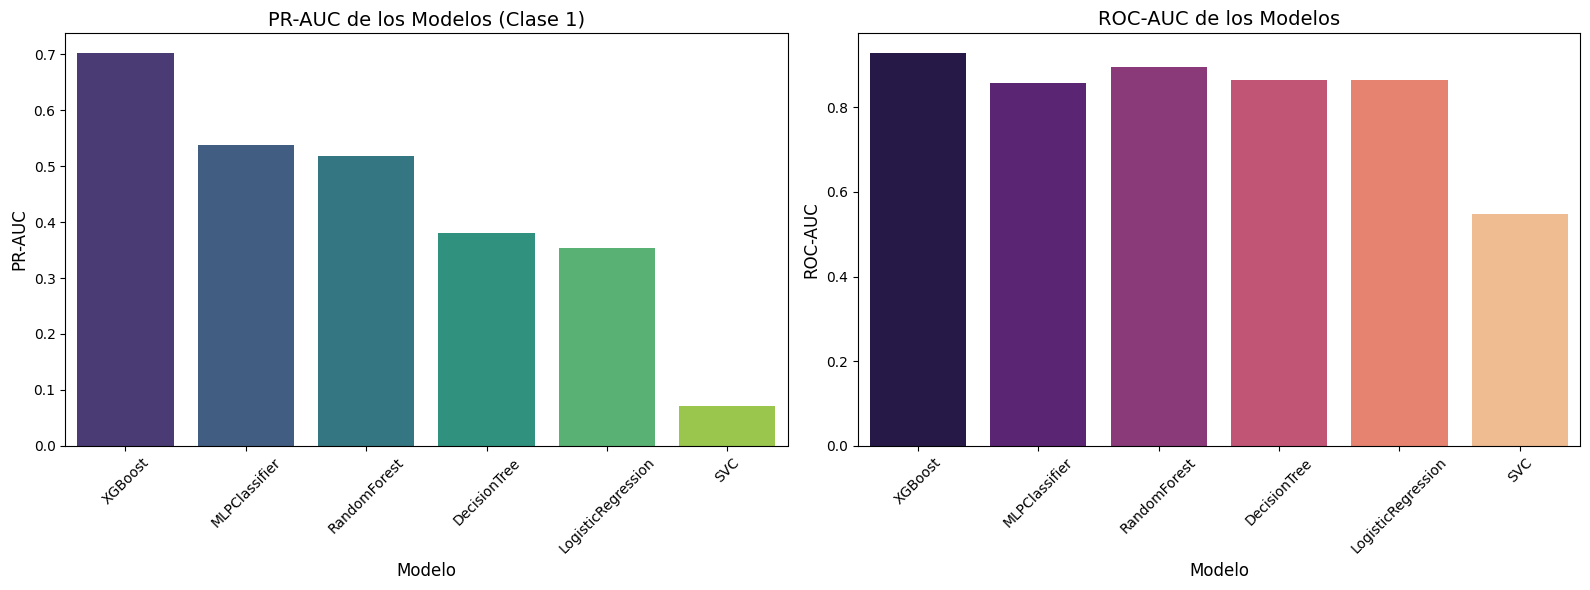


Modelos con mejor rendimiento según PR-AUC:
          Modelo    PR-AUC
3        XGBoost  0.702364
4  MLPClassifier  0.537146
2   RandomForest  0.517421


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("---- RESUMEN DE RENDIMIENTO DE MODELOS ----")

# Crear un DataFrame con las métricas de rendimiento
performance_summary = []
for model_name, metrics in model_performance.items():
    performance_summary.append({
        'Modelo': model_name,
        'ROC-AUC': metrics['roc_auc'],
        'PR-AUC': metrics['pr_auc'],
        'Precision_Class1': metrics['report']['1']['precision'],
        'Recall_Class1': metrics['report']['1']['recall'],
        'F1_Score_Class1': metrics['report']['1']['f1-score']
    })

performance_df = pd.DataFrame(performance_summary)
performance_df = performance_df.sort_values(by='PR-AUC', ascending=False)

display(performance_df)

# Visualización de las métricas principales (PR-AUC y ROC-AUC)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x='Modelo', y='PR-AUC', data=performance_df, palette='viridis')
axes[0].set_title('PR-AUC de los Modelos (Clase 1)', fontsize=14)
axes[0].set_ylabel('PR-AUC', fontsize=12)
axes[0].set_xlabel('Modelo', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x='Modelo', y='ROC-AUC', data=performance_df, palette='magma')
axes[1].set_title('ROC-AUC de los Modelos', fontsize=14)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_xlabel('Modelo', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nModelos con mejor rendimiento según PR-AUC:")
print(performance_df[['Modelo', 'PR-AUC']].head(3))

## Optimización de Hiperparámetros


Se realiza la optimización de hiperparámetros utilizando `RandomizedSearchCV` con validación cruzada (`StratifiedKFold`) para los dos modelos con mejor rendimiento. Se evaluan con `scoring='average_precision'`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

print("---- OPTIMIZACIÓN DE HIPERPARÁMETROS PARA XGBoost ----")

xgb_model_full = xgb.XGBClassifier(
    random_state=SEED,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum()
)

# Definir el espacio de búsqueda de hiperparámetros
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5)
}

# Configurar RandomizedSearchCV
rscv_xgb = RandomizedSearchCV(
    estimator=xgb_model_full,
    param_distributions=param_dist_xgb,
    n_iter=50, # Número de combinaciones de hiperparámetros a probar
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    verbose=1,
    random_state=SEED,
    n_jobs=-1 # Usar todos los núcleos disponibles
)

# Ejecutar la búsqueda
rscv_xgb.fit(X_train_final, y_train)

print("\nMejores hiperparámetros para XGBoost:")
print(rscv_xgb.best_params_)
print(f"Mejor PR-AUC (XGBoost) en validación cruzada: {rscv_xgb.best_score_:.4f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_xgb_model = rscv_xgb.best_estimator_

best_xgb_preds = best_xgb_model.predict(X_test_final)
best_xgb_proba = best_xgb_model.predict_proba(X_test_final)[:, 1]

roc_auc_tuned_xgb = roc_auc_score(y_test, best_xgb_proba)
pr_auc_tuned_xgb = average_precision_score(y_test, best_xgb_proba)

print("\nReporte de Clasificación (XGBoost - Tuned):")
print(classification_report(y_test, best_xgb_preds))

print(f"ROC-AUC (XGBoost - Tuned): {roc_auc_tuned_xgb:.4f}")
print(f"PR-AUC (XGBoost - Tuned): {pr_auc_tuned_xgb:.4f}")

model_performance['XGBoost_Tuned'] = {
    'roc_auc': roc_auc_tuned_xgb,
    'pr_auc': pr_auc_tuned_xgb,
    'report': classification_report(y_test, best_xgb_preds, output_dict=True),
    'best_params': rscv_xgb.best_params_
}

print("\nXGBoost optimizado y evaluado.")

---- OPTIMIZACIÓN DE HIPERPARÁMETROS PARA XGBoost ----
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros para XGBoost:
{'colsample_bytree': np.float64(0.8912865394447438), 'gamma': np.float64(0.1838915663596266), 'learning_rate': np.float64(0.13646116611871592), 'max_depth': 8, 'n_estimators': 494, 'subsample': np.float64(0.9265727492877536)}
Mejor PR-AUC (XGBoost) en validación cruzada: 0.7550

Reporte de Clasificación (XGBoost - Tuned):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     20713
           1       0.89      0.67      0.76       535

    accuracy                           0.99     21248
   macro avg       0.94      0.83      0.88     21248
weighted avg       0.99      0.99      0.99     21248

ROC-AUC (XGBoost - Tuned): 0.9500
PR-AUC (XGBoost - Tuned): 0.7943

XGBoost optimizado y evaluado.


## Reducción de Dimensionalidad

Aplicación de PCA (Análisis de Componentes Principales) y UMAP (Uniform Manifold Approximation and Projection) al conjunto de características reducido (`X_final_features`) para explorar una mayor compresión y su impacto en el rendimiento del modelo.

In [ ]:
from sklearn.preprocessing import StandardScaler

print("---- PREPARANDO DATOS PARA REDUCCIÓN DE DIMENSIONALIDAD ----")

# Escalar los datos
scaler_dim_reduction = StandardScaler()
X_train_scaled = scaler_dim_reduction.fit_transform(X_train_final)
X_test_scaled = scaler_dim_reduction.transform(X_test_final)

print("Datos de entrenamiento escalados. Forma:", X_train_scaled.shape)
print("Datos de prueba escalados. Forma:", X_test_scaled.shape)

---- PREPARANDO DATOS PARA REDUCCIÓN DE DIMENSIONALIDAD ----
Datos de entrenamiento escalados. Forma: (84991, 239)
Datos de prueba escalados. Forma: (21248, 239)


In [ ]:
from sklearn.decomposition import PCA

print("---- APLICANDO PCA ----")

# Ajustar PCA en los datos de entrenamiento escalados
pca = PCA(n_components=0.95, random_state=SEED) # Retener el 95% de la varianza
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Número de componentes seleccionados por PCA: {pca.n_components_}")
print(f"Varianza explicada acumulada por los componentes de PCA: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Shape de X_train_pca: {X_train_pca.shape}")
print(f"Shape de X_test_pca: {X_test_pca.shape}")

---- APLICANDO PCA ----
Número de componentes seleccionados por PCA: 110
Varianza explicada acumulada por los componentes de PCA: 0.9510
Shape de X_train_pca: (84991, 110)
Shape de X_test_pca: (21248, 110)


### Aplicación de UMAP

In [ ]:
import umap

print("---- APLICANDO UMAP ----")

# Ajustar UMAP en los datos de entrenamiento escalados
# Se usa un número de componentes razonable (e.g., 2 para visualización, o mayor para modelado)
umap_reducer = umap.UMAP(n_components=2, random_state=SEED)

X_train_umap = umap_reducer.fit_transform(X_train_scaled)
X_test_umap = umap_reducer.transform(X_test_scaled)

print(f"Shape de X_train_umap: {X_train_umap.shape}")
print(f"Shape de X_test_umap: {X_test_umap.shape}")

---- APLICANDO UMAP ----
Shape de X_train_umap: (84991, 2)
Shape de X_test_umap: (21248, 2)


## Comparación de Estrategias de Dimensionalidad Reducida

Se entrena el modelo optimizado de XGBoost en los conjuntos de datos reducidos por PCA y UMAP. Se evalua su rendimiento utilizando las mismas métricas (ROC-AUC, PR-AUC, etc.) y se comparan los resultados con el modelo XGBoost optimizado que se entrenó sin reducción de dimensionalidad.

In [ ]:
print("---- ENTRENAMIENTO Y EVALUACIÓN DE XGBoost CON PCA ----")

# Obtener los mejores parámetros del XGBoost optimizado
best_xgb_params = model_performance['XGBoost_Tuned']['best_params']

# Re-inicializar el modelo XGBoost con los parámetros óptimos
# y los ajustes específicos para el desbalance de clases
model_pca = xgb.XGBClassifier(
    random_state=SEED,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
    **best_xgb_params
)

# Entrenar el modelo en los datos reducidos por PCA
model_pca.fit(X_train_pca, y_train)

# Predicciones en el conjunto de prueba PCA
preds_pca = model_pca.predict(X_test_pca)
proba_pca = model_pca.predict_proba(X_test_pca)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (XGBoost con PCA):")
print(classification_report(y_test, preds_pca))

roc_auc_pca = roc_auc_score(y_test, proba_pca)
pr_auc_pca = average_precision_score(y_test, proba_pca)

print(f"ROC-AUC (XGBoost con PCA): {roc_auc_pca:.4f}")
print(f"PR-AUC (XGBoost con PCA): {pr_auc_pca:.4f}")

# Almacenar métricas para comparación futura
model_performance['XGBoost_PCA'] = {
    'roc_auc': roc_auc_pca,
    'pr_auc': pr_auc_pca,
    'report': classification_report(y_test, preds_pca, output_dict=True)
}

print("\nXGBoost con PCA entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE XGBoost CON PCA ----

Reporte de Clasificación (XGBoost con PCA):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     20713
           1       0.83      0.40      0.54       535

    accuracy                           0.98     21248
   macro avg       0.91      0.70      0.77     21248
weighted avg       0.98      0.98      0.98     21248

ROC-AUC (XGBoost con PCA): 0.8957
PR-AUC (XGBoost con PCA): 0.5799

XGBoost con PCA entrenado y evaluado.


In [ ]:
print("---- ENTRENAMIENTO Y EVALUACIÓN DE XGBoost CON UMAP ----")

# Re-inicializar el modelo XGBoost con los parámetros óptimos
model_umap = xgb.XGBClassifier(
    random_state=SEED,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
    **best_xgb_params
)

# Entrenar el modelo en los datos reducidos por UMAP
model_umap.fit(X_train_umap, y_train)

# Predicciones en el conjunto de prueba UMAP
preds_umap = model_umap.predict(X_test_umap)
proba_umap = model_umap.predict_proba(X_test_umap)[:, 1]

# Evaluar el rendimiento
print("\nReporte de Clasificación (XGBoost con UMAP):")
print(classification_report(y_test, preds_umap))

roc_auc_umap = roc_auc_score(y_test, proba_umap)
pr_auc_umap = average_precision_score(y_test, proba_umap)

print(f"ROC-AUC (XGBoost con UMAP): {roc_auc_umap:.4f}")
print(f"PR-AUC (XGBoost con UMAP): {pr_auc_umap:.4f}")

# Almacenar métricas para comparación futura
model_performance['XGBoost_UMAP'] = {
    'roc_auc': roc_auc_umap,
    'pr_auc': pr_auc_umap,
    'report': classification_report(y_test, preds_umap, output_dict=True)
}

print("\nXGBoost con UMAP entrenado y evaluado.")

---- ENTRENAMIENTO Y EVALUACIÓN DE XGBoost CON UMAP ----

Reporte de Clasificación (XGBoost con UMAP):
              precision    recall  f1-score   support

           0       0.99      0.75      0.85     20713
           1       0.06      0.65      0.11       535

    accuracy                           0.75     21248
   macro avg       0.53      0.70      0.48     21248
weighted avg       0.96      0.75      0.84     21248

ROC-AUC (XGBoost con UMAP): 0.7696
PR-AUC (XGBoost con UMAP): 0.1860

XGBoost con UMAP entrenado y evaluado.


---- RESUMEN DE RENDIMIENTO DE MODELOS CON Y SIN REDUCCIÓN DE DIMENSIONALIDAD ----


,Modelo,ROC-AUC,PR-AUC,Precision_Class1,Recall_Class1,F1_Score_Class1
0,XGBoost_Tuned,0.950025,0.794328,0.890274,0.667290,0.762821
1,XGBoost_PCA,0.895749,0.579866,0.829457,0.400000,0.539723
2,XGBoost_UMAP,0.769626,0.185969,0.063024,0.646729,0.114855


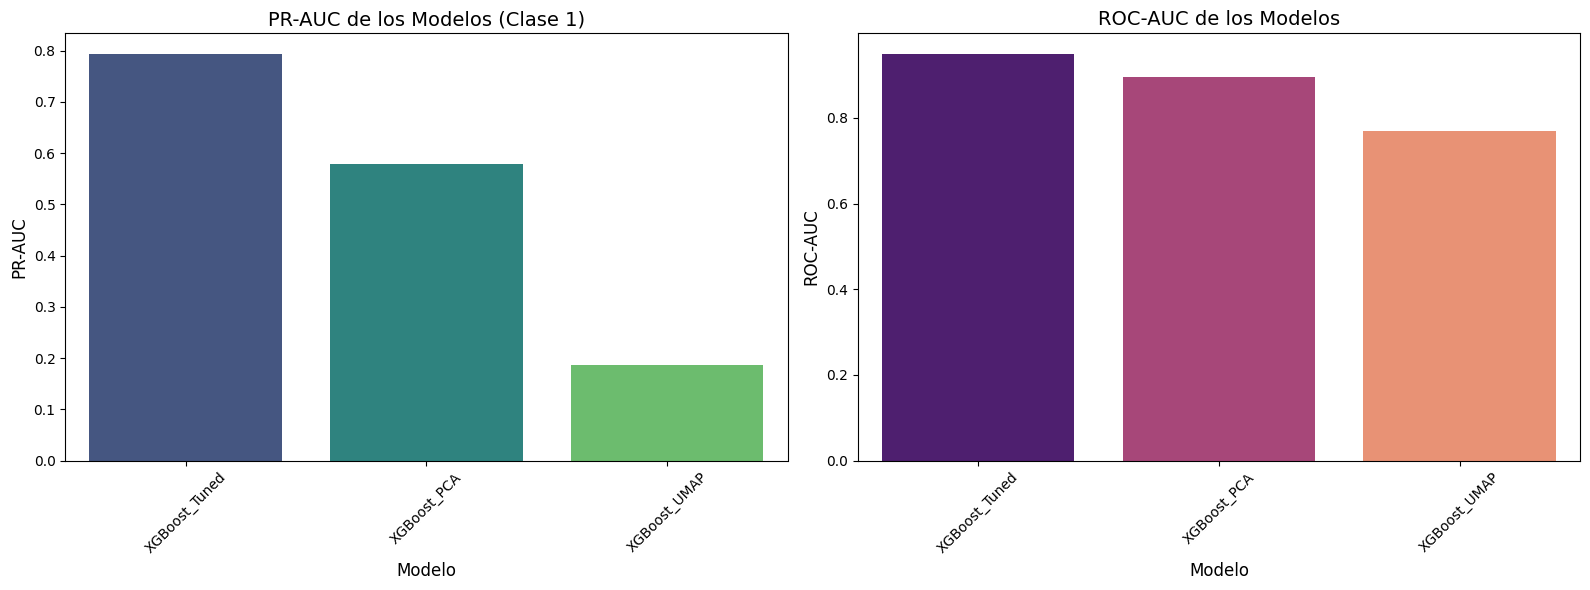


Mejor estrategia de reducción de dimensionalidad (según PR-AUC):
          Modelo    PR-AUC
0  XGBoost_Tuned  0.794328


In [ ]:
print("---- RESUMEN DE RENDIMIENTO DE MODELOS CON Y SIN REDUCCIÓN DE DIMENSIONALIDAD ----")

# Crear un DataFrame con las métricas de rendimiento
performance_summary_dim_reduction = []
for model_name, metrics in model_performance.items():
    # Only include relevant models for this comparison
    if model_name in ['XGBoost_Tuned', 'XGBoost_PCA', 'XGBoost_UMAP']:
        performance_summary_dim_reduction.append({
            'Modelo': model_name,
            'ROC-AUC': metrics['roc_auc'],
            'PR-AUC': metrics['pr_auc'],
            'Precision_Class1': metrics['report']['1']['precision'],
            'Recall_Class1': metrics['report']['1']['recall'],
            'F1_Score_Class1': metrics['report']['1']['f1-score']
        })

performance_df_dim_reduction = pd.DataFrame(performance_summary_dim_reduction)
performance_df_dim_reduction = performance_df_dim_reduction.sort_values(by='PR-AUC', ascending=False)

display(performance_df_dim_reduction)

# Visualización de las métricas principales (PR-AUC y ROC-AUC)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x='Modelo', y='PR-AUC', data=performance_df_dim_reduction, palette='viridis')
axes[0].set_title('PR-AUC de los Modelos (Clase 1)', fontsize=14)
axes[0].set_ylabel('PR-AUC', fontsize=12)
axes[0].set_xlabel('Modelo', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x='Modelo', y='ROC-AUC', data=performance_df_dim_reduction, palette='magma')
axes[1].set_title('ROC-AUC de los Modelos', fontsize=14)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_xlabel('Modelo', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nMejor estrategia de reducción de dimensionalidad (según PR-AUC):")
print(performance_df_dim_reduction[['Modelo', 'PR-AUC']].head(1))

## Evaluación Final del Modelo

---- EVALUACIÓN FINAL DEL MODELO ELEGIDO (XGBoost TUNED) ----

Reporte de Clasificación Final (XGBoost Tuned):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     20713
           1       0.89      0.67      0.76       535

    accuracy                           0.99     21248
   macro avg       0.94      0.83      0.88     21248
weighted avg       0.99      0.99      0.99     21248

ROC-AUC Final: 0.9500
PR-AUC Final: 0.7943


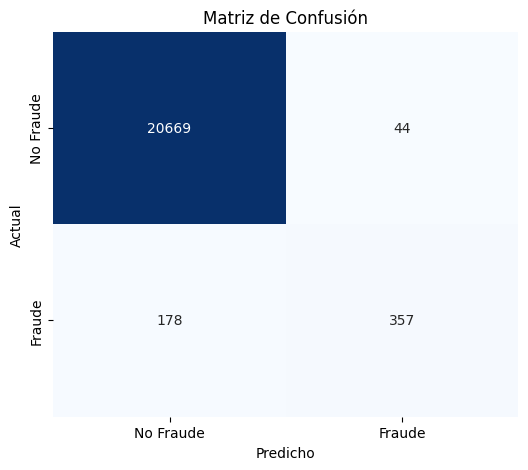

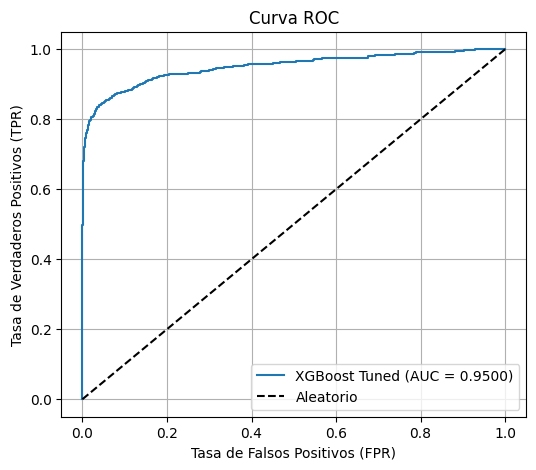

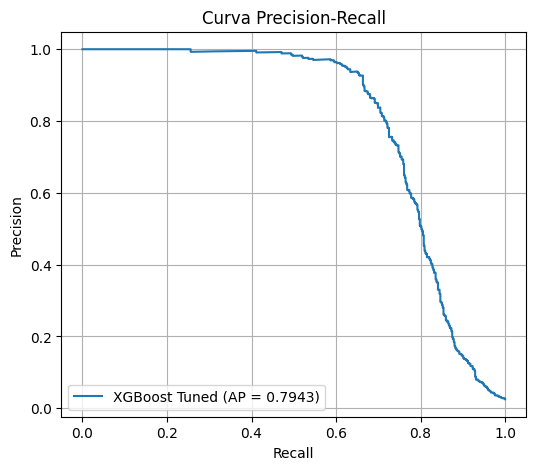


Evaluación final del modelo completada.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

print("---- EVALUACIÓN FINAL DEL MODELO ELEGIDO (XGBoost TUNED) ----")

# El mejor modelo XGBoost ya fue entrenado en X_train_final durante RandomizedSearchCV
# y es accessible a través de best_xgb_model

# Predicciones en el conjunto de prueba (unseen)
final_preds = best_xgb_model.predict(X_test_final)
final_proba = best_xgb_model.predict_proba(X_test_final)[:, 1]

# 1. Reporte de Clasificación
print("\nReporte de Clasificación Final (XGBoost Tuned):")
print(classification_report(y_test, final_preds))

# 2. Métricas Clave
roc_auc_final = roc_auc_score(y_test, final_proba)
pr_auc_final = average_precision_score(y_test, final_proba)

print(f"ROC-AUC Final: {roc_auc_final:.4f}")
print(f"PR-AUC Final: {pr_auc_final:.4f}")

# 3. Matriz de Confusión
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

# 4. Curva ROC
fpr, tpr, _ = roc_curve(y_test, final_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost Tuned (AUC = {roc_auc_final:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

# 5. Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, final_proba)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'XGBoost Tuned (AP = {pr_auc_final:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

print("\nEvaluación final del modelo completada.")

### Exportar el Modelo Final

In [ ]:
import joblib

# Definir el nombre del archivo para guardar el modelo
model_filename = 'best_xgboost_model.joblib'

# Guardar el modelo en disco
joblib.dump(best_xgb_model, model_filename)

print(f"El modelo final de XGBoost ha sido exportado exitosamente a '{model_filename}'")

El modelo final de XGBoost ha sido exportado exitosamente a 'best_xgboost_model.joblib'
